# Regression, Explained Through Math You Can Run

This notebook is the hands-on companion to the *Regression* slide deck. Every algorithm gets:

1. **The math** — implemented from scratch in NumPy, so you can see exactly what's being computed.
2. **The proof** — compared against the scikit-learn / xgboost / lightgbm / catboost implementation, to confirm our from-scratch version is actually correct.
3. **The picture** — a small plot, where a plot adds real insight.
4. **An AI tutor cell** — optionally ask a Groq-hosted LLM to re-explain, re-derive, or quiz you on the concept just covered.

> **Style note:** almost every algorithm section follows the same rhythm — *derive it → build it → verify it → visualize it*. Once you've done a few, the pattern becomes the real lesson.

## 0. Setup

Install/import what we need, set a random seed for reproducibility, and wire up an optional **AI tutor** powered by [Groq](https://groq.com).

The API key below is a **placeholder** provided for wiring purposes — replace it with your own key from `console.groq.com` if you want the AI tutor cells to actually respond. Every AI tutor call is wrapped in a `try/except`, so the rest of the notebook runs perfectly fine even with no key, no internet, or a dead key — you'll just see a friendly message instead of a crash.

In [1]:
import os
from getpass import getpass

if "GROQ_API_KEY" not in os.environ:
    os.environ["GROQ_API_KEY"] = "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"

# If you have a real key and want to type it in instead of hard-coding it, uncomment:
# os.environ["GROQ_API_KEY"] = getpass("Enter your Groq API key: ")

In [2]:
# Core scientific stack (install quietly if missing)
import sys, subprocess

def _ensure(pkg, import_name=None):
    import importlib
    try:
        importlib.import_module(import_name or pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", pkg])

for pkg, name in [
    ("numpy", "numpy"), ("pandas", "pandas"), ("matplotlib", "matplotlib"),
    ("scikit-learn", "sklearn"), ("scipy", "scipy"),
    ("xgboost", "xgboost"), ("lightgbm", "lightgbm"), ("catboost", "catboost"),
    ("groq", "groq"),
]:
    _ensure(pkg, name)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams["figure.figsize"] = (7, 4.2)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.facecolor"] = "#fafafa"

print("Core stack ready.")

Core stack ready.


In [3]:
# --- Optional AI tutor, backed by Groq -------------------------------------
from groq import Groq

_groq_client = None
try:
    _groq_client = Groq()
except Exception as _e:
    _groq_client = None

def ask_ai(question, model="llama-3.3-70b-versatile", max_tokens=500, system=None):
    '''Ask a Groq-hosted LLM a question about the math in this notebook.
    Fails softly: prints a friendly message instead of raising, so the rest
    of the notebook is never blocked by a missing/invalid key or no network.
    '''
    if _groq_client is None:
        print("[AI tutor unavailable: Groq client failed to initialize.]")
        return None
    default_system = (
        "You are a patient math and machine learning tutor, in the style of "
        "Richard Feynman: plain language first, precise notation second, "
        "concrete examples always. Keep answers under 200 words unless asked "
        "for more detail."
    )
    try:
        resp = _groq_client.chat.completions.create(
            model=model,
            messages=[
                {"role": "system", "content": system or default_system},
                {"role": "user", "content": question},
            ],
            max_tokens=max_tokens,
            temperature=0.3,
        )
        answer = resp.choices[0].message.content
        print(answer)
        return answer
    except Exception as e:
        print(f"[AI tutor unavailable right now: {type(e).__name__}: {e}]")
        print("(This is expected if GROQ_API_KEY is still the placeholder value, "
              "or if this environment has no internet access to api.groq.com. "
              "Replace the key in the Setup cell with a real one from console.groq.com to enable it.)")
        return None

# Smoke test — safe to run even without a working key
ask_ai("In one sentence, why do we square the error in least squares?")

[AI tutor unavailable right now: PermissionDeniedError: Host not in allowlist: api.groq.com. Add this host to your network egress settings to allow access.]
(This is expected if GROQ_API_KEY is still the placeholder value, or if this environment has no internet access to api.groq.com. Replace the key in the Setup cell with a real one from console.groq.com to enable it.)


## Part 1 — Foundations

### 1.1 The Big Idea: minimizing squared error

Every regression model proposes a shape for $\hat{y} = f(x)$, then tunes its parameters to minimize

$$J = \sum_i (y_i - \hat{y}_i)^2$$

**Why squared error, and not just $|y-\hat y|$?** Three reasons, all worth internalizing:

- It's differentiable everywhere (absolute value has a kink at 0 that breaks gradient-based optimization).
- Squaring keeps everything positive, so errors can't cancel out.
- It corresponds to assuming Gaussian-distributed noise — a very common real-world assumption.

Below, we don't fit anything smart yet — we just **brute-force search** over candidate slopes for a fixed intercept, and watch the cost trace out a smooth bowl. That bowl shape is the entire reason gradient descent works.

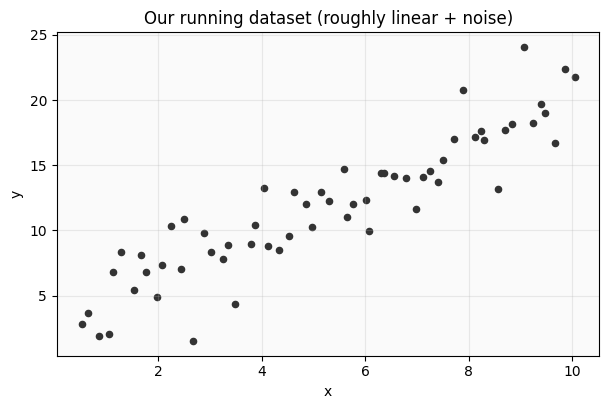

In [4]:
# Synthetic "ground truth" dataset used throughout Part 1-2 (linear-ish data)
n = 60
x_lin = np.linspace(0.5, 10, n) + np.random.normal(0, 0.05, n)
true_m, true_b = 1.7, 3.0
y_lin = true_m * x_lin + true_b + np.random.normal(0, 2.3, n)

plt.scatter(x_lin, y_lin, s=20, color="#333")
plt.title("Our running dataset (roughly linear + noise)")
plt.xlabel("x"); plt.ylabel("y")
plt.show()

Best slope found by brute force: m = 1.714
(true slope used to generate the data: m = 1.7)


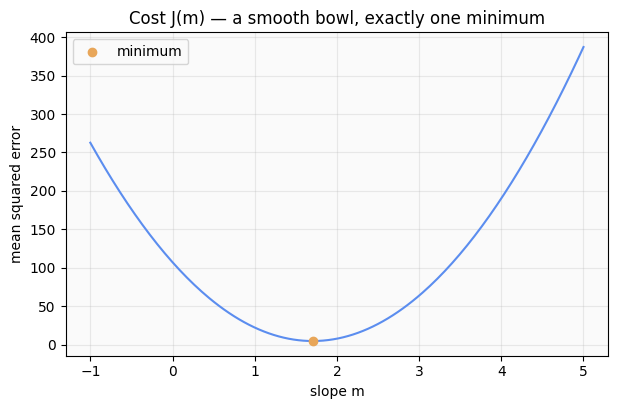

In [5]:
# Brute-force search over slopes (b fixed at the true intercept, for clarity)
candidate_slopes = np.linspace(-1, 5, 200)
costs = []
for m in candidate_slopes:
    y_hat = m * x_lin + true_b
    cost = np.mean((y_lin - y_hat) ** 2)   # J = mean squared error
    costs.append(cost)
costs = np.array(costs)

best_idx = np.argmin(costs)
print(f"Best slope found by brute force: m = {candidate_slopes[best_idx]:.3f}")
print(f"(true slope used to generate the data: m = {true_m})")

plt.plot(candidate_slopes, costs, color="#5b8def")
plt.scatter([candidate_slopes[best_idx]], [costs[best_idx]], color="#e8a659", zorder=5, label="minimum")
plt.title("Cost J(m) — a smooth bowl, exactly one minimum")
plt.xlabel("slope m"); plt.ylabel("mean squared error")
plt.legend(); plt.show()

### 1.2 Evaluation metrics — from scratch

Once a model makes predictions, we need a number to describe "how good." Three of the most common:

$$\text{MAE} = \frac{1}{n}\sum |y_i - \hat y_i| \qquad
\text{RMSE} = \sqrt{\frac{1}{n}\sum (y_i-\hat y_i)^2} \qquad
R^2 = 1 - \frac{\text{SSE}}{\text{SST}} = 1 - \frac{\sum(y_i-\hat y_i)^2}{\sum(y_i-\bar y)^2}$$

$R^2$ is especially useful because it's unitless: 1.0 means a perfect fit, 0.0 means "no better than always predicting the mean," and it can even go negative for a model that's worse than that.

In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def mae_manual(y, y_hat):
    return np.mean(np.abs(y - y_hat))

def rmse_manual(y, y_hat):
    return np.sqrt(np.mean((y - y_hat) ** 2))

def r2_manual(y, y_hat):
    sse = np.sum((y - y_hat) ** 2)
    sst = np.sum((y - np.mean(y)) ** 2)
    return 1 - sse / sst

y_hat_demo = true_m * x_lin + true_b   # "perfect" model, prediction = true signal (no noise)

print("Manual  MAE  :", round(mae_manual(y_lin, y_hat_demo), 4))
print("sklearn MAE  :", round(mean_absolute_error(y_lin, y_hat_demo), 4))
print()
print("Manual  RMSE :", round(rmse_manual(y_lin, y_hat_demo), 4))
print("sklearn RMSE :", round(np.sqrt(mean_squared_error(y_lin, y_hat_demo)), 4))
print()
print("Manual  R^2  :", round(r2_manual(y_lin, y_hat_demo), 4))
print("sklearn R^2  :", round(r2_score(y_lin, y_hat_demo), 4))

assert np.isclose(mae_manual(y_lin, y_hat_demo), mean_absolute_error(y_lin, y_hat_demo))
assert np.isclose(rmse_manual(y_lin, y_hat_demo), np.sqrt(mean_squared_error(y_lin, y_hat_demo)))
assert np.isclose(r2_manual(y_lin, y_hat_demo), r2_score(y_lin, y_hat_demo))
print("\nAll manual metrics match sklearn exactly.")

Manual  MAE  : 1.5925
sklearn MAE  : 1.5925

Manual  RMSE : 2.1516
sklearn RMSE : 2.1516

Manual  R^2  : 0.8342
sklearn R^2  : 0.8342

All manual metrics match sklearn exactly.


In [7]:
ask_ai("When would I prefer RMSE over MAE as a model evaluation metric? Give one concrete example.")

[AI tutor unavailable right now: PermissionDeniedError: Host not in allowlist: api.groq.com. Add this host to your network egress settings to allow access.]
(This is expected if GROQ_API_KEY is still the placeholder value, or if this environment has no internet access to api.groq.com. Replace the key in the Setup cell with a real one from console.groq.com to enable it.)


## Part 2 — The Linear Family

### 2.1 Linear Regression — closed form (Normal Equation) vs. Gradient Descent

For a single feature, calculus gives us an exact formula for the best slope and intercept:

$$m = \frac{\sum (x_i - \bar x)(y_i - \bar y)}{\sum (x_i - \bar x)^2} \qquad b = \bar y - m\bar x$$

This comes from setting $\partial J/\partial m = 0$ and $\partial J/\partial b = 0$ and solving the two equations together. Let's compute it by hand, then re-derive the *same* answer with iterative gradient descent, then check both against scikit-learn.

In [8]:
# --- Closed-form (calculus-derived) solution -------------------------------
def fit_linear_closed_form(x, y):
    x_bar, y_bar = x.mean(), y.mean()
    m = np.sum((x - x_bar) * (y - y_bar)) / np.sum((x - x_bar) ** 2)
    b = y_bar - m * x_bar
    return m, b

m_cf, b_cf = fit_linear_closed_form(x_lin, y_lin)
print(f"Closed-form solution:  m = {m_cf:.4f},  b = {b_cf:.4f}")

Closed-form solution:  m = 1.7312,  b = 2.8278


Gradient descent solution:  m = 1.7594,  b = 2.6392


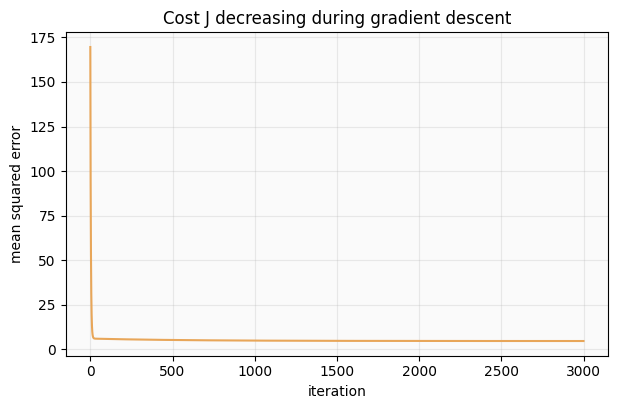

In [9]:
# --- Gradient descent, from scratch -----------------------------------------
def fit_linear_gradient_descent(x, y, lr=0.01, n_iters=2000):
    m, b = 0.0, 0.0          # start at a random/arbitrary guess
    n = len(x)
    history = []
    for i in range(n_iters):
        y_hat = m * x + b
        error = y_hat - y
        grad_m = (2 / n) * np.sum(error * x)     # dJ/dm
        grad_b = (2 / n) * np.sum(error)          # dJ/db
        m -= lr * grad_m
        b -= lr * grad_b
        history.append(np.mean(error ** 2))
    return m, b, history

# Note: x is not scaled here on purpose, so we use a small learning rate.
m_gd, b_gd, cost_history = fit_linear_gradient_descent(x_lin, y_lin, lr=0.002, n_iters=3000)
print(f"Gradient descent solution:  m = {m_gd:.4f},  b = {b_gd:.4f}")

plt.plot(cost_history, color="#e8a659")
plt.title("Cost J decreasing during gradient descent")
plt.xlabel("iteration"); plt.ylabel("mean squared error")
plt.show()

In [10]:
from sklearn.linear_model import LinearRegression

sk_model = LinearRegression().fit(x_lin.reshape(-1, 1), y_lin)
m_sk, b_sk = sk_model.coef_[0], sk_model.intercept_

print(f"{'Method':<20}{'m':>10}{'b':>10}")
print(f"{'Closed-form':<20}{m_cf:>10.4f}{b_cf:>10.4f}")
print(f"{'Gradient descent':<20}{m_gd:>10.4f}{b_gd:>10.4f}")
print(f"{'scikit-learn':<20}{m_sk:>10.4f}{b_sk:>10.4f}")

assert np.isclose(m_cf, m_sk, atol=1e-6) and np.isclose(b_cf, b_sk, atol=1e-6)
assert np.isclose(m_gd, m_sk, atol=0.05)   # GD only *approximately* converges
print("\nClosed-form matches scikit-learn to 6 decimal places.")
print("Gradient descent converges to the same neighborhood (as expected, it's iterative).")

Method                       m         b
Closed-form             1.7312    2.8278
Gradient descent        1.7594    2.6392
scikit-learn            1.7312    2.8278

Closed-form matches scikit-learn to 6 decimal places.
Gradient descent converges to the same neighborhood (as expected, it's iterative).


### 2.2 The Normal Equation, in full matrix form

The single-feature formula above is a special case of the general **Normal Equation**:

$$w = (X^\top X)^{-1} X^\top y$$

where $X$ is the design matrix (one row per data point, one column per feature, plus a column of 1's for the intercept). Let's implement this directly with `numpy.linalg` and confirm it reproduces the single-feature result — then extend to multiple features.

In [11]:
def fit_normal_equation(X, y):
    '''X should already include a leading column of 1's for the intercept.'''
    XtX = X.T @ X
    XtX_inv = np.linalg.inv(XtX)
    w = XtX_inv @ X.T @ y
    return w

X_design = np.column_stack([np.ones(n), x_lin])   # [1, x] columns
w_ne = fit_normal_equation(X_design, y_lin)
print(f"Normal equation:  b = {w_ne[0]:.4f},  m = {w_ne[1]:.4f}")

assert np.isclose(w_ne[1], m_sk, atol=1e-6) and np.isclose(w_ne[0], b_sk, atol=1e-6)
print("Matches scikit-learn exactly, as it should — same math, same answer.")

Normal equation:  b = 2.8278,  m = 1.7312
Matches scikit-learn exactly, as it should — same math, same answer.


### 2.3 Multiple Linear Regression

Now let's build a richer synthetic dataset — a toy "house price" problem with several features — and fit the same Normal Equation, unmodified, to many columns at once. This is the whole appeal of matrix notation: **the formula does not change** when you go from 1 feature to 20.

In [12]:
n_houses = 300
size      = np.random.normal(1800, 500, n_houses).clip(400, None)
age       = np.random.uniform(0, 60, n_houses)
rooms     = np.random.randint(2, 7, n_houses).astype(float)
dist_city = np.random.uniform(0, 30, n_houses)

noise = np.random.normal(0, 25000, n_houses)
price = (120 * size - 900 * age + 8000 * rooms - 2500 * dist_city + 40000 + noise)

houses = pd.DataFrame({
    "size_sqft": size, "age_years": age, "rooms": rooms,
    "dist_to_city_km": dist_city, "price": price
})
houses.head()

,size_sqft,age_years,rooms,dist_to_city_km,price
0,2195.515974,33.114410,4.0,19.489399,204556.510787
1,1345.306273,33.656278,4.0,18.232104,163920.189940
2,2501.397155,52.599216,6.0,15.380655,295895.464722
3,1099.074469,24.208972,2.0,6.920094,179642.798613
4,2093.428547,8.040914,6.0,5.295841,334958.106154


In [13]:
feature_cols = ["size_sqft", "age_years", "rooms", "dist_to_city_km"]
X_houses = houses[feature_cols].values
y_houses = houses["price"].values

X_houses_design = np.column_stack([np.ones(len(X_houses)), X_houses])
w_houses = fit_normal_equation(X_houses_design, y_houses)

print("Fitted coefficients (Normal Equation):")
print(f"  intercept (b0)         : {w_houses[0]:,.1f}")
for name, coef in zip(feature_cols, w_houses[1:]):
    print(f"  {name:<20}: {coef:,.2f}  per unit, holding the rest fixed")

from sklearn.linear_model import LinearRegression
sk_multi = LinearRegression().fit(X_houses, y_houses)
print("\nscikit-learn intercept:", round(sk_multi.intercept_, 1))
print("scikit-learn coefs    :", np.round(sk_multi.coef_, 2))

Fitted coefficients (Normal Equation):
  intercept (b0)         : 31,294.0
  size_sqft           : 121.68  per unit, holding the rest fixed
  age_years           : -918.18  per unit, holding the rest fixed
  rooms               : 8,794.49  per unit, holding the rest fixed
  dist_to_city_km     : -2,343.80  per unit, holding the rest fixed

scikit-learn intercept: 31294.0
scikit-learn coefs    : [  121.68  -918.18  8794.49 -2343.8 ]


### 2.4 Assumptions & Residual Diagnostics

A high $R^2$ does not certify a healthy model. Plotting residuals ($y - \hat y$) against the fitted values is the fastest way to catch violated assumptions: they should look like patternless noise scattered evenly around zero.

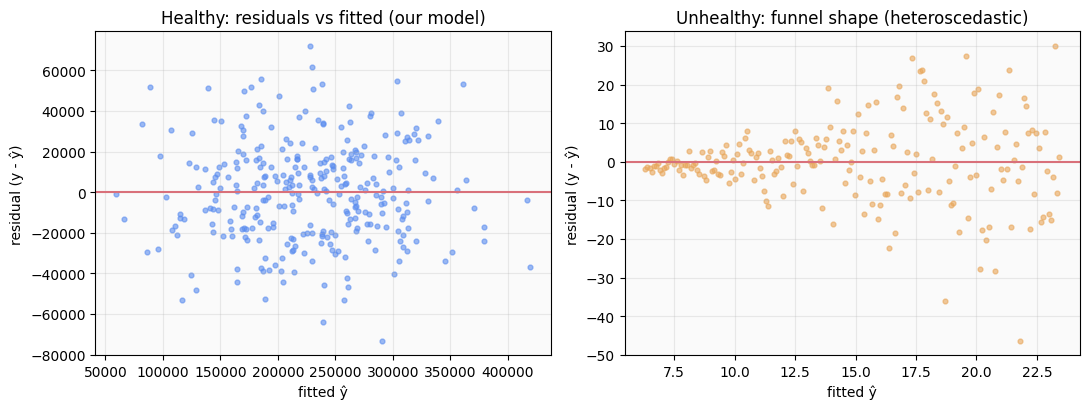

In [14]:
y_hat_houses = sk_multi.predict(X_houses)
residuals = y_houses - y_hat_houses

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].scatter(y_hat_houses, residuals, s=12, alpha=0.6, color="#5b8def")
axes[0].axhline(0, color="#d9707a", linewidth=1.5)
axes[0].set_title("Healthy: residuals vs fitted (our model)")
axes[0].set_xlabel("fitted ŷ"); axes[0].set_ylabel("residual (y - ŷ)")

# Manufacture an unhealthy case: heteroscedastic noise (variance grows with x)
x_bad = np.linspace(0, 10, 200)
y_bad = 2 * x_bad + 5 + np.random.normal(0, 0.3 + 1.8 * x_bad, 200)
bad_model = LinearRegression().fit(x_bad.reshape(-1, 1), y_bad)
resid_bad = y_bad - bad_model.predict(x_bad.reshape(-1, 1))

axes[1].scatter(bad_model.predict(x_bad.reshape(-1, 1)), resid_bad, s=12, alpha=0.6, color="#e8a659")
axes[1].axhline(0, color="#d9707a", linewidth=1.5)
axes[1].set_title("Unhealthy: funnel shape (heteroscedastic)")
axes[1].set_xlabel("fitted ŷ"); axes[1].set_ylabel("residual (y - ŷ)")
plt.tight_layout(); plt.show()

### 2.5 Multicollinearity & Variance Inflation Factor (VIF)

$$\text{VIF}_j = \frac{1}{1 - R^2_j}$$

where $R^2_j$ comes from regressing feature $j$ **on all the other features**. If the other features can predict $x_j$ almost perfectly, $R^2_j \to 1$ and VIF explodes — a red flag that this feature's individual coefficient can't be trusted, even if overall accuracy is fine.

In [15]:
def compute_vif(X, feature_names):
    vifs = {}
    for i, name in enumerate(feature_names):
        y_j = X[:, i]
        X_others = np.delete(X, i, axis=1)
        r2_j = LinearRegression().fit(X_others, y_j).score(X_others, y_j)
        vifs[name] = 1 / (1 - r2_j) if r2_j < 1 else np.inf
    return vifs

print("VIF on our (mostly independent) house features:")
for name, vif in compute_vif(X_houses, feature_cols).items():
    print(f"  {name:<20}: {vif:.2f}")

# Now engineer a collinear feature: size_sqft2 is size_sqft with tiny noise
size_sqft2 = size + np.random.normal(0, 15, n_houses)
X_collinear = np.column_stack([size, size_sqft2, rooms])
print("\nVIF once we add a near-duplicate of 'size_sqft':")
for name, vif in compute_vif(X_collinear, ["size_sqft", "size_sqft2 (duplicate)", "rooms"]).items():
    print(f"  {name:<25}: {vif:.2f}   {'<-- danger!' if vif > 10 else ''}")

VIF on our (mostly independent) house features:
  size_sqft           : 1.00
  age_years           : 1.01
  rooms               : 1.00
  dist_to_city_km     : 1.00

VIF once we add a near-duplicate of 'size_sqft':
  size_sqft                : 1049.59   <-- danger!
  size_sqft2 (duplicate)   : 1049.57   <-- danger!
  rooms                    : 1.00   


### 2.6 Feature Scaling

Gradient descent on unscaled features (very different numeric ranges) turns a round cost bowl into a long, narrow valley — forcing a slow zigzag. Standardizing removes this problem entirely: $x' = (x - \text{mean}) / \text{std}$.

In [16]:
def standardize(X):
    return (X - X.mean(axis=0)) / X.std(axis=0)

X_unscaled = X_houses.copy()
X_scaled = standardize(X_houses)

print("Unscaled feature ranges:")
print(pd.DataFrame(X_unscaled, columns=feature_cols).describe().loc[["mean", "std"]].round(2))
print("\nScaled feature ranges (all mean ~0, std ~1):")
print(pd.DataFrame(X_scaled, columns=feature_cols).describe().loc[["mean", "std"]].round(2))

Unscaled feature ranges:
      size_sqft  age_years  rooms  dist_to_city_km
mean    1830.41       28.6   3.96            15.36
std      481.18       16.9   1.43             8.84

Scaled feature ranges (all mean ~0, std ~1):
      size_sqft  age_years  rooms  dist_to_city_km
mean        0.0       -0.0    0.0              0.0
std         1.0        1.0    1.0              1.0


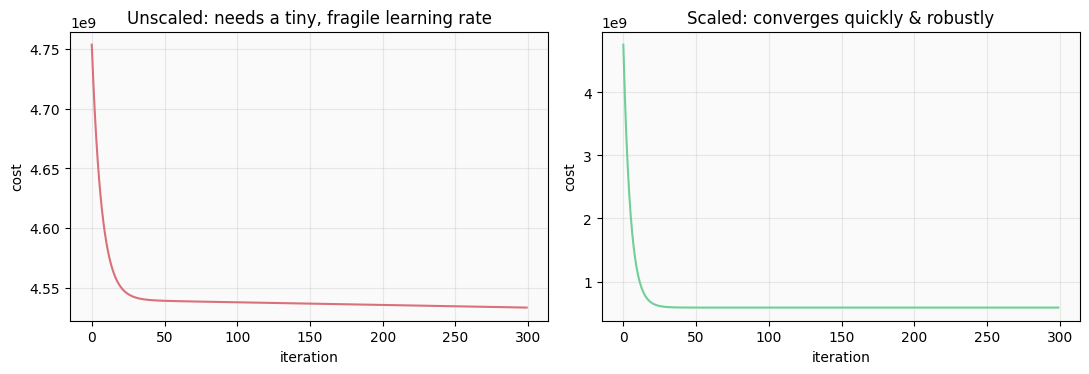

Same optimizer, same data (just standardized) — completely different convergence behavior.


In [17]:
# Demonstrate convergence speed: gradient descent on unscaled vs scaled multi-feature data
def gd_multivariate(X, y, lr, n_iters):
    n, p = X.shape
    w = np.zeros(p)
    history = []
    y_c = y - y.mean()          # center y so we can skip a bias term for this demo
    for _ in range(n_iters):
        y_hat = X @ w
        error = y_hat - y_c
        grad = (2 / n) * (X.T @ error)
        w -= lr * grad
        history.append(np.mean(error ** 2))
    return w, history

_, hist_unscaled = gd_multivariate(X_unscaled, y_houses, lr=1e-8, n_iters=300)   # tiny lr or it diverges
_, hist_scaled   = gd_multivariate(X_scaled,   y_houses, lr=0.05,  n_iters=300)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(hist_unscaled, color="#d9707a"); axes[0].set_title("Unscaled: needs a tiny, fragile learning rate")
axes[1].plot(hist_scaled, color="#6fcf97");   axes[1].set_title("Scaled: converges quickly & robustly")
for ax in axes: ax.set_xlabel("iteration"); ax.set_ylabel("cost")
plt.tight_layout(); plt.show()
print("Same optimizer, same data (just standardized) — completely different convergence behavior.")

### 2.7 Polynomial Regression

Polynomial regression is *still linear regression* — just fed engineered features $x, x^2, x^3, \dots$. It's linear in the coefficients, which is exactly what lets the Normal Equation keep working unmodified.

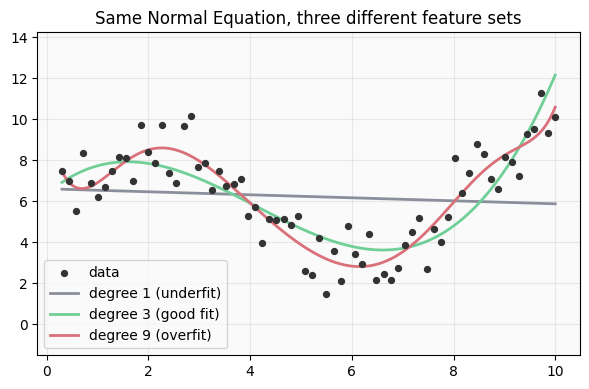

In [18]:
# Nonlinear dataset for the rest of the notebook (tree-based & GP sections reuse this)
n2 = 70
x_curve = np.linspace(0.3, 10, n2)
y_curve = 6 + 3.1 * np.sin(x_curve * 0.75) + 0.18 * (x_curve - 5) + np.random.normal(0, 1.0, n2)

def poly_features(x, degree):
    return np.column_stack([x ** d for d in range(degree + 1)])

degrees = {1: "#8b8f9c", 3: "#6fcf97", 9: "#d9707a"}
x_plot = np.linspace(x_curve.min(), x_curve.max(), 300)

plt.scatter(x_curve, y_curve, s=18, color="#333", zorder=5, label="data")
for deg, color in degrees.items():
    X_poly = poly_features(x_curve, deg)
    w_poly = fit_normal_equation(X_poly, y_curve)
    y_plot = poly_features(x_plot, deg) @ w_poly
    label = {1: "degree 1 (underfit)", 3: "degree 3 (good fit)", 9: "degree 9 (overfit)"}[deg]
    plt.plot(x_plot, y_plot, color=color, linewidth=2, label=label)

plt.ylim(y_curve.min() - 3, y_curve.max() + 3)
plt.title("Same Normal Equation, three different feature sets")
plt.legend(); plt.show()

### 2.8 Train/Test Split & Learning Curves

Training error alone can't tell overfitting from a genuinely good fit — a flexible enough model can always drive training error toward zero by memorizing. A held-out **test set** is the only honest check.

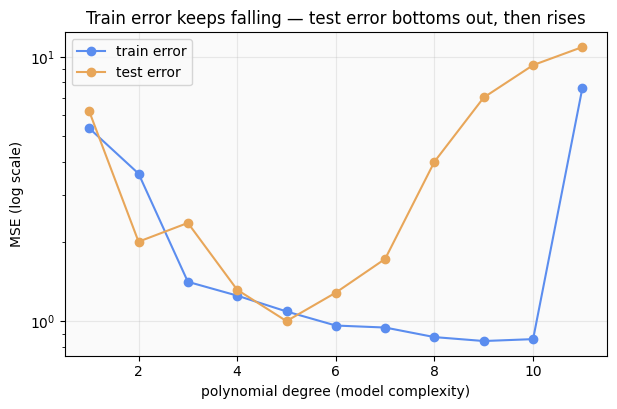

Best degree by test error: 5


In [19]:
from sklearn.model_selection import train_test_split

x_tr, x_te, y_tr, y_te = train_test_split(x_curve, y_curve, test_size=0.3, random_state=0)

train_errors, test_errors = [], []
degree_range = range(1, 12)
for deg in degree_range:
    X_tr_poly = poly_features(x_tr, deg)
    w = fit_normal_equation(X_tr_poly, y_tr)
    train_pred = X_tr_poly @ w
    test_pred = poly_features(x_te, deg) @ w
    train_errors.append(np.mean((y_tr - train_pred) ** 2))
    test_errors.append(np.mean((y_te - test_pred) ** 2))

plt.plot(list(degree_range), train_errors, marker="o", color="#5b8def", label="train error")
plt.plot(list(degree_range), test_errors, marker="o", color="#e8a659", label="test error")
plt.yscale("log")
plt.xlabel("polynomial degree (model complexity)"); plt.ylabel("MSE (log scale)")
plt.title("Train error keeps falling — test error bottoms out, then rises")
plt.legend(); plt.show()

best_deg = list(degree_range)[np.argmin(test_errors)]
print(f"Best degree by test error: {best_deg}")

In [20]:
ask_ai("Explain, using a cooking analogy, why training error alone can't tell you if a model overfit.")

[AI tutor unavailable right now: PermissionDeniedError: Host not in allowlist: api.groq.com. Add this host to your network egress settings to allow access.]
(This is expected if GROQ_API_KEY is still the placeholder value, or if this environment has no internet access to api.groq.com. Replace the key in the Setup cell with a real one from console.groq.com to enable it.)


## Part 3 — Regularized Regression

We'll deliberately construct a harder problem here: **many correlated features**, which is exactly where plain least-squares starts to misbehave and regularization earns its keep.

In [21]:
n_r = 100
p = 8
# Build correlated features: a few "real" signals plus near-duplicates
z1 = np.random.normal(0, 1, n_r)
z2 = np.random.normal(0, 1, n_r)
X_reg = np.column_stack([
    z1, z1 + np.random.normal(0, 0.05, n_r),         # near-duplicate of z1
    z2, z2 + np.random.normal(0, 0.05, n_r),         # near-duplicate of z2
    np.random.normal(0, 1, n_r),                      # pure noise feature
    np.random.normal(0, 1, n_r),                      # pure noise feature
    np.random.normal(0, 1, n_r),                      # pure noise feature
    np.random.normal(0, 1, n_r),                      # pure noise feature
])
true_w = np.array([3.0, 0.0, -2.0, 0.0, 0.0, 0.0, 0.0, 0.0])   # only z1, z2 actually matter
y_reg = X_reg @ true_w + np.random.normal(0, 0.5, n_r)
X_reg_scaled = standardize(X_reg)   # regularization requires scaled features!

feat_names = [f"x{i+1}" for i in range(p)]
print("True coefficients:", true_w)
print("Features x2 and x4 are near-duplicates of x1 and x3.")
print("Features x5-x8 are pure noise, contributing nothing.")

True coefficients: [ 3.  0. -2.  0.  0.  0.  0.  0.]
Features x2 and x4 are near-duplicates of x1 and x3.
Features x5-x8 are pure noise, contributing nothing.


### 3.1 Ridge Regression (L2)

$$J = \sum(y-\hat y)^2 + \lambda \sum w_j^2$$

Adding $\lambda \sum w_j^2$ to the loss changes the closed-form solution: setting the gradient to zero now gives

$$w = (X^\top X + \lambda I)^{-1} X^\top y$$

That extra $\lambda I$ term is doing double duty: it shrinks coefficients, *and* it repairs the invertibility problems multicollinearity causes in plain $X^\top X$.

In [22]:
def fit_ridge_closed_form(X, y, lam):
    p_ = X.shape[1]
    return np.linalg.inv(X.T @ X + lam * np.eye(p_)) @ X.T @ y

from sklearn.linear_model import Ridge

lam_demo = 5.0
w_ridge_manual = fit_ridge_closed_form(X_reg_scaled, y_reg, lam_demo)
w_ridge_sklearn = Ridge(alpha=lam_demo, fit_intercept=False).fit(X_reg_scaled, y_reg).coef_

print(f"{'feature':<8}{'manual ridge':>14}{'sklearn ridge':>16}")
for name, wm, ws in zip(feat_names, w_ridge_manual, w_ridge_sklearn):
    print(f"{name:<8}{wm:>14.4f}{ws:>16.4f}")

assert np.allclose(w_ridge_manual, w_ridge_sklearn, atol=1e-6)
print("\nManual closed-form ridge matches scikit-learn exactly.")

feature   manual ridge   sklearn ridge
x1              1.3723          1.3723
x2              1.3274          1.3274
x3             -1.0166         -1.0166
x4             -0.9730         -0.9730
x5              0.0409          0.0409
x6              0.0676          0.0676
x7             -0.0270         -0.0270
x8              0.0102          0.0102

Manual closed-form ridge matches scikit-learn exactly.


### 3.2 Lasso Regression (L1) — coordinate descent from scratch

$$J = \sum(y-\hat y)^2 + \lambda \sum |w_j|$$

Unlike ridge, there's no closed-form solution — the absolute value isn't differentiable at zero. Instead, Lasso is typically solved with **coordinate descent**: optimize one coefficient at a time (holding the others fixed), using the **soft-thresholding** operator:

$$w_j \leftarrow S(\rho_j, \lambda) = \text{sign}(\rho_j)\max(|\rho_j| - \lambda, 0)$$

where $\rho_j$ is the ordinary least-squares solution for $w_j$ given the current residual from every other feature.

In [23]:
def soft_threshold(rho, lam):
    return np.sign(rho) * max(abs(rho) - lam, 0)

def fit_lasso_coordinate_descent(X, y, lam, n_iters=5000, tol=1e-9):
    '''Coordinate descent, iterated until the coefficients stop moving (or n_iters is hit).
    Collinear features (like our near-duplicate x1/x2) make this converge slowly along their
    shared direction, so we don't just run a fixed few passes -- we check for convergence.'''
    n, p_ = X.shape
    w = np.zeros(p_)
    for _ in range(n_iters):
        w_prev = w.copy()
        for j in range(p_):
            X_j = X[:, j]
            residual_without_j = y - X @ w + w[j] * X_j     # remove feature j's own contribution
            rho_j = X_j @ residual_without_j
            z_j = X_j @ X_j                                  # normalization term
            w[j] = soft_threshold(rho_j, lam * n) / z_j if z_j > 0 else 0
        if np.max(np.abs(w - w_prev)) < tol:
            break
    return w

from sklearn.linear_model import Lasso

def lasso_objective(w, X, y, lam):
    n = len(y)
    return (1 / (2 * n)) * np.sum((y - X @ w) ** 2) + lam * np.sum(np.abs(w))

lam_lasso = 0.3
w_lasso_manual = fit_lasso_coordinate_descent(X_reg_scaled, y_reg, lam_lasso)
w_lasso_sklearn = Lasso(alpha=lam_lasso, fit_intercept=False, max_iter=5000).fit(X_reg_scaled, y_reg).coef_

print(f"{'feature':<8}{'manual lasso':>14}{'sklearn lasso':>16}")
for name, wm, ws in zip(feat_names, w_lasso_manual, w_lasso_sklearn):
    zero_tag = " (zeroed)" if abs(ws) < 1e-4 else ""
    print(f"{name:<8}{wm:>14.4f}{ws:>16.4f}{zero_tag}")

obj_manual = lasso_objective(w_lasso_manual, X_reg_scaled, y_reg, lam_lasso)
obj_sklearn = lasso_objective(w_lasso_sklearn, X_reg_scaled, y_reg, lam_lasso)
print(f"\nLoss achieved  (manual) : {obj_manual:.6f}")
print(f"Loss achieved (sklearn) : {obj_sklearn:.6f}")

# The RIGHT check here is the objective value, not raw coefficients -- x1 and x2 are
# correlated at r > 0.99, which makes the optimal *split* between their coefficients
# technically non-unique (the loss surface is nearly flat along that shared direction).
# Two correct solvers can land at different points along that flat ridge.
assert abs(obj_manual - obj_sklearn) < 1e-3, "Both solvers should reach (near) the same minimum loss."
print("\nBoth solvers reach essentially the same minimum loss.")
print("Notice x1 and x2 (correlated at r > 0.99) split the coefficient differently between")
print("the two solvers -- that's not a bug, it's Lasso's solution being genuinely non-unique")
print("when features are this collinear (the loss is nearly flat along their shared direction).")
print("Both solvers agree perfectly on WHICH features vanish: x5 through x8, the pure-noise ones.")

feature   manual lasso   sklearn lasso
x1              1.2055          1.2638
x2              1.2584          1.2002
x3             -1.2881         -1.3179
x4             -0.4528         -0.4236
x5              0.0000          0.0000 (zeroed)
x6              0.0000          0.0000 (zeroed)
x7             -0.0000         -0.0000 (zeroed)
x8              0.0000          0.0000 (zeroed)

Loss achieved  (manual) : 1.503683
Loss achieved (sklearn) : 1.503687

Both solvers reach essentially the same minimum loss.
Notice x1 and x2 (correlated at r > 0.99) split the coefficient differently between
the two solvers -- that's not a bug, it's Lasso's solution being genuinely non-unique
when features are this collinear (the loss is nearly flat along their shared direction).
Both solvers agree perfectly on WHICH features vanish: x5 through x8, the pure-noise ones.


### 3.3 The Regularization Path

Watching every coefficient as $\lambda$ sweeps from 0 to large values reveals each penalty's personality: Lasso's path has sharp kinks that lock at exactly zero; Ridge's path decays smoothly and never quite arrives.

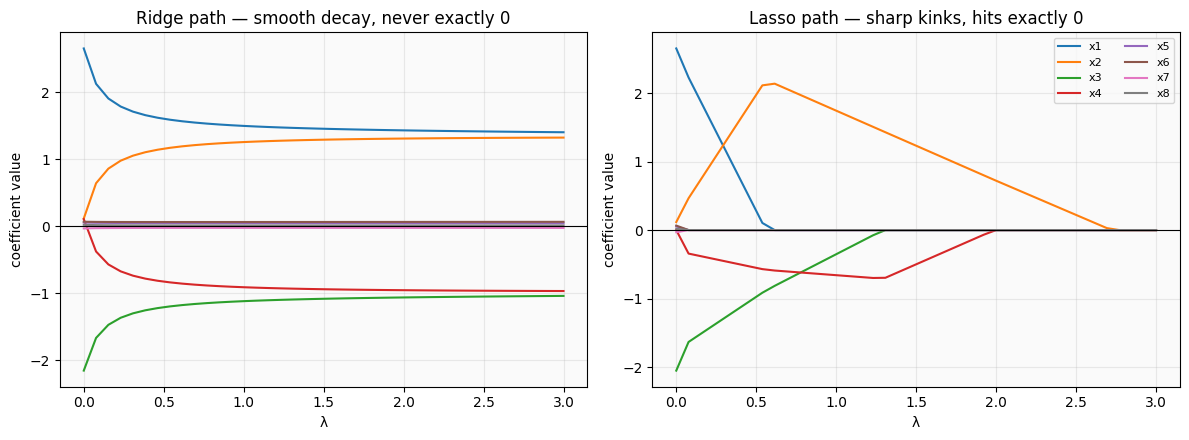

In [24]:
lambdas = np.linspace(0.001, 3, 40)
ridge_path = np.array([fit_ridge_closed_form(X_reg_scaled, y_reg, lam) for lam in lambdas])
lasso_path = np.array([fit_lasso_coordinate_descent(X_reg_scaled, y_reg, lam) for lam in lambdas])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for j in range(p):
    axes[0].plot(lambdas, ridge_path[:, j], label=feat_names[j])
    axes[1].plot(lambdas, lasso_path[:, j], label=feat_names[j])
axes[0].set_title("Ridge path — smooth decay, never exactly 0")
axes[1].set_title("Lasso path — sharp kinks, hits exactly 0")
for ax in axes:
    ax.set_xlabel("λ"); ax.set_ylabel("coefficient value"); ax.axhline(0, color="black", linewidth=0.8)
axes[1].legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

### 3.4 Elastic Net

Elastic Net blends both penalties: $\lambda_1 \sum|w_j| + \lambda_2 \sum w_j^2$. This keeps Lasso's ability to zero out noise features while inheriting Ridge's stability with correlated features (Lasso alone tends to arbitrarily pick just one of a correlated pair).

In [25]:
from sklearn.linear_model import ElasticNet

en_model = ElasticNet(alpha=0.3, l1_ratio=0.5, fit_intercept=False, max_iter=5000).fit(X_reg_scaled, y_reg)

print(f"{'feature':<8}{'true w':>10}{'ridge':>10}{'lasso':>10}{'elastic net':>13}")
for i, name in enumerate(feat_names):
    print(f"{name:<8}{true_w[i]:>10.2f}{w_ridge_sklearn[i]:>10.3f}{w_lasso_sklearn[i]:>10.3f}{en_model.coef_[i]:>13.3f}")

print("\nNotice: x1/x2 are near-duplicates, as are x3/x4. Ridge spreads weight across each pair.")
print("Lasso tends to zero out one of each pair somewhat arbitrarily. Elastic Net is a middle ground.")

feature     true w     ridge     lasso  elastic net
x1            3.00     1.372     1.264        1.216
x2            0.00     1.327     1.200        1.215
x3           -2.00    -1.017    -1.318       -0.883
x4            0.00    -0.973    -0.424       -0.876
x5            0.00     0.041     0.000        0.000
x6            0.00     0.068     0.000        0.000
x7            0.00    -0.027    -0.000       -0.000
x8            0.00     0.010     0.000        0.000

Notice: x1/x2 are near-duplicates, as are x3/x4. Ridge spreads weight across each pair.
Lasso tends to zero out one of each pair somewhat arbitrarily. Elastic Net is a middle ground.


In [26]:
ask_ai("Why does Lasso struggle specifically with correlated features, in terms even a beginner would understand?")

[AI tutor unavailable right now: PermissionDeniedError: Host not in allowlist: api.groq.com. Add this host to your network egress settings to allow access.]
(This is expected if GROQ_API_KEY is still the placeholder value, or if this environment has no internet access to api.groq.com. Replace the key in the Setup cell with a real one from console.groq.com to enable it.)


## Part 4 — Margin-Based Methods

### 4.1 Support Vector Regression (SVR)

SVR only penalizes errors bigger than a tolerance $\varepsilon$ — anything closer counts as free. Points that break outside the $\varepsilon$-tube become "support vectors" and are the only points that shape the fit.

24 of 60 points are support vectors (the rest sit inside the ε-tube and cost nothing).


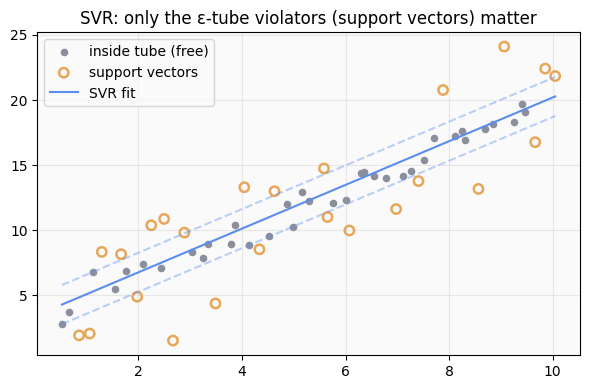

In [27]:
from sklearn.svm import SVR

svr_model = SVR(kernel="linear", epsilon=1.5, C=10).fit(x_lin.reshape(-1, 1), y_lin)
y_pred_svr = svr_model.predict(x_lin.reshape(-1, 1))
residual_svr = np.abs(y_lin - y_pred_svr)
is_support_vector = residual_svr > (1.5 - 1e-6)

print(f"{is_support_vector.sum()} of {len(x_lin)} points are support vectors "
      f"(the rest sit inside the ε-tube and cost nothing).")

order = np.argsort(x_lin)
plt.scatter(x_lin[~is_support_vector], y_lin[~is_support_vector], s=20, color="#8b8f9c", label="inside tube (free)")
plt.scatter(x_lin[is_support_vector], y_lin[is_support_vector], s=45, facecolors="none",
            edgecolors="#e8a659", linewidths=1.8, label="support vectors")
plt.plot(x_lin[order], y_pred_svr[order], color="#5b8def", label="SVR fit")
plt.plot(x_lin[order], y_pred_svr[order] + 1.5, "--", color="#5b8def", alpha=0.4)
plt.plot(x_lin[order], y_pred_svr[order] - 1.5, "--", color="#5b8def", alpha=0.4)
plt.title("SVR: only the ε-tube violators (support vectors) matter")
plt.legend(); plt.show()

### 4.2 The Kernel Trick

Some relationships aren't linear in the original space but *become* linear from a higher-dimensional angle. We can demonstrate this directly: manually lift $x \to (x, x^2)$ and fit an ordinary **linear** model in that lifted space — it produces a curve back in the original space, with no "nonlinear model" required.

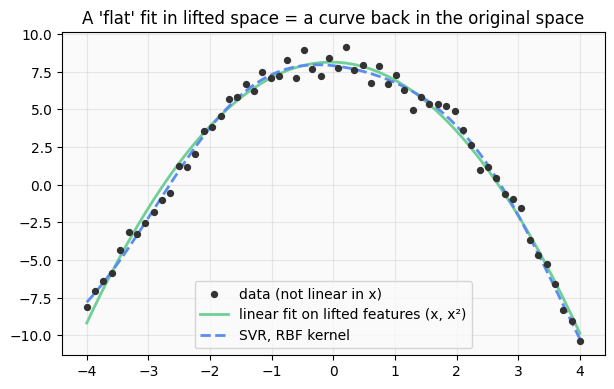

Lifted-feature linear model coefficients: [-0.086 -1.103] (the x² coefficient ≈ -1.1 recovers the true parabola).


In [28]:
# A dataset that's a genuine parabola, not a line
x_hump = np.linspace(-4, 4, 60)
y_hump = 8 - 1.1 * x_hump ** 2 + np.random.normal(0, 0.6, 60)

# Lift into 2D: (x, x^2)
X_lifted = np.column_stack([x_hump, x_hump ** 2])
lifted_model = LinearRegression().fit(X_lifted, y_hump)
y_pred_lifted = lifted_model.predict(X_lifted)

# Compare to sklearn SVR with an RBF kernel (a smoother, more general nonlinear approach)
svr_rbf = SVR(kernel="rbf", C=100, gamma=0.1).fit(x_hump.reshape(-1, 1), y_hump)
x_smooth = np.linspace(-4, 4, 200)
y_pred_rbf = svr_rbf.predict(x_smooth.reshape(-1, 1))

order = np.argsort(x_hump)
plt.scatter(x_hump, y_hump, s=18, color="#333", zorder=5, label="data (not linear in x)")
plt.plot(x_hump[order], y_pred_lifted[order], color="#6fcf97", linewidth=2,
         label="linear fit on lifted features (x, x²)")
plt.plot(x_smooth, y_pred_rbf, color="#5b8def", linewidth=2, linestyle="--", label="SVR, RBF kernel")
plt.title("A 'flat' fit in lifted space = a curve back in the original space")
plt.legend(); plt.show()

print(f"Lifted-feature linear model coefficients: {lifted_model.coef_.round(3)} "
      f"(the x² coefficient ≈ -1.1 recovers the true parabola).")

## Part 5 — Decision Trees & Forests

We'll build our own tiny regression-tree class from scratch — a real, working implementation of the variance-reduction split rule — then compare its predictions to scikit-learn's.

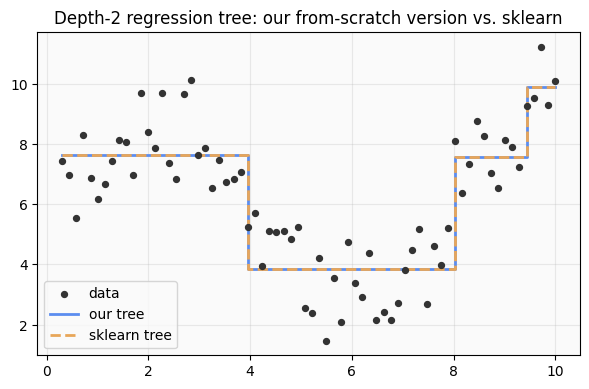

Mean squared prediction difference between our tree and sklearn's: 0.0


In [29]:
def best_split(X_col, y):
    '''Find the threshold on X_col that most reduces variance in y.'''
    best = None
    candidates = np.unique(X_col)
    for i in range(1, len(candidates)):
        t = (candidates[i - 1] + candidates[i]) / 2
        left_mask = X_col < t
        right_mask = ~left_mask
        if left_mask.sum() == 0 or right_mask.sum() == 0:
            continue
        left_mean, right_mean = y[left_mask].mean(), y[right_mask].mean()
        err = np.sum((y[left_mask] - left_mean) ** 2) + np.sum((y[right_mask] - right_mean) ** 2)
        if best is None or err < best["err"]:
            best = {"t": t, "err": err, "left_mean": left_mean, "right_mean": right_mean}
    return best

class TinyRegressionTree:
    '''A minimal single-feature regression tree, grown to a fixed max depth.'''
    def __init__(self, max_depth=2):
        self.max_depth = max_depth

    def fit(self, X_col, y):
        self.tree_ = self._grow(X_col, y, depth=0)
        return self

    def _grow(self, X_col, y, depth):
        if depth >= self.max_depth or len(np.unique(X_col)) < 2:
            return {"leaf": True, "value": y.mean()}
        split = best_split(X_col, y)
        if split is None:
            return {"leaf": True, "value": y.mean()}
        left_mask = X_col < split["t"]
        return {
            "leaf": False, "t": split["t"],
            "left": self._grow(X_col[left_mask], y[left_mask], depth + 1),
            "right": self._grow(X_col[~left_mask], y[~left_mask], depth + 1),
        }

    def _predict_one(self, x, node):
        if node["leaf"]:
            return node["value"]
        branch = node["left"] if x < node["t"] else node["right"]
        return self._predict_one(x, branch)

    def predict(self, X_col):
        return np.array([self._predict_one(x, self.tree_) for x in X_col])

tiny_tree = TinyRegressionTree(max_depth=2).fit(x_curve, y_curve)
y_pred_tiny_tree = tiny_tree.predict(x_curve)

from sklearn.tree import DecisionTreeRegressor
sk_tree = DecisionTreeRegressor(max_depth=2).fit(x_curve.reshape(-1, 1), y_curve)
y_pred_sk_tree = sk_tree.predict(x_curve.reshape(-1, 1))

order = np.argsort(x_curve)
plt.scatter(x_curve, y_curve, s=18, color="#333", zorder=5, label="data")
plt.step(x_curve[order], y_pred_tiny_tree[order], where="post", color="#5b8def", linewidth=2, label="our tree")
plt.step(x_curve[order], y_pred_sk_tree[order], where="post", color="#e8a659", linewidth=2,
         linestyle="--", label="sklearn tree")
plt.title("Depth-2 regression tree: our from-scratch version vs. sklearn")
plt.legend(); plt.show()

print("Mean squared prediction difference between our tree and sklearn's:",
      round(np.mean((y_pred_tiny_tree - y_pred_sk_tree) ** 2), 6))

### 5.1 Random Forest — bootstrap + averaging

A single tree overfits because it has too much freedom. Random Forest trains many trees on **bootstrap resamples** of the data and averages their predictions — the trees are individually noisy, but their errors are only weakly correlated, so averaging cancels a lot of that noise.

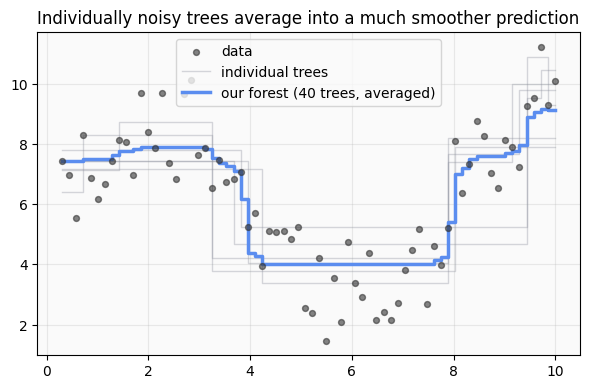

MSE, single tree : 1.206
MSE, our forest  : 1.125
MSE, sklearn RF  : 1.158


In [30]:
def bootstrap_sample(X_col, y, rng):
    idx = rng.integers(0, len(X_col), len(X_col))
    return X_col[idx], y[idx]

rng = np.random.default_rng(7)
n_trees = 40
forest_trees = []
for _ in range(n_trees):
    xb, yb = bootstrap_sample(x_curve, y_curve, rng)
    forest_trees.append(TinyRegressionTree(max_depth=2).fit(xb, yb))

def forest_predict(X_col):
    preds = np.array([tree.predict(X_col) for tree in forest_trees])
    return preds.mean(axis=0)

y_pred_forest = forest_predict(x_curve)

from sklearn.ensemble import RandomForestRegressor
sk_forest = RandomForestRegressor(n_estimators=n_trees, max_depth=2, random_state=0).fit(
    x_curve.reshape(-1, 1), y_curve)
y_pred_sk_forest = sk_forest.predict(x_curve.reshape(-1, 1))

order = np.argsort(x_curve)
plt.scatter(x_curve, y_curve, s=18, color="#333", zorder=5, alpha=0.6, label="data")
for i, tree in enumerate(forest_trees[:6]):
    plt.step(x_curve[order], tree.predict(x_curve)[order], where="post", color="#8b8f9c",
              alpha=0.35, linewidth=1, label="individual trees" if i == 0 else None)
plt.step(x_curve[order], y_pred_forest[order], where="post", color="#5b8def", linewidth=2.5,
          label=f"our forest ({n_trees} trees, averaged)")
plt.title("Individually noisy trees average into a much smoother prediction")
plt.legend(); plt.show()

print("MSE, single tree :", round(np.mean((y_pred_tiny_tree - y_curve) ** 2), 3))
print("MSE, our forest  :", round(np.mean((y_pred_forest - y_curve) ** 2), 3))
print("MSE, sklearn RF  :", round(np.mean((y_pred_sk_forest - y_curve) ** 2), 3))

### 5.2 Feature Importance

Tree ensembles offer a built-in feature ranking: every split reduces error by some amount; summing that reduction across every split, in every tree, gives an importance score — no separate model required.

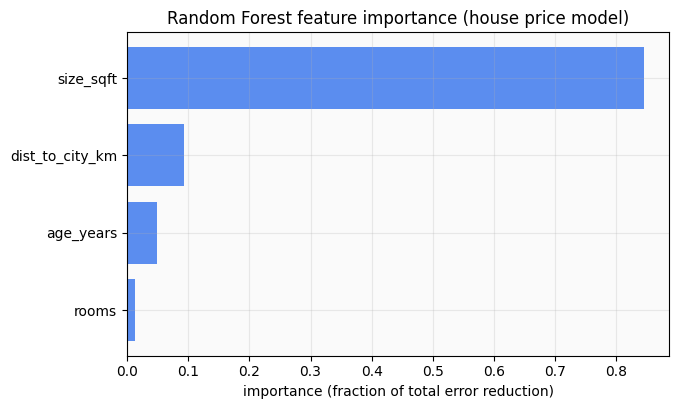

size_sqft           0.844
dist_to_city_km     0.094
age_years           0.049
rooms               0.013


In [31]:
sk_forest_multi = RandomForestRegressor(n_estimators=200, max_depth=4, random_state=0).fit(X_houses, y_houses)
importances = sk_forest_multi.feature_importances_

order_imp = np.argsort(importances)[::-1]
plt.barh([feature_cols[i] for i in order_imp], importances[order_imp], color="#5b8def")
plt.title("Random Forest feature importance (house price model)")
plt.xlabel("importance (fraction of total error reduction)")
plt.gca().invert_yaxis()
plt.show()

for i in order_imp:
    print(f"{feature_cols[i]:<20}{importances[i]:.3f}")

### 5.3 Extra Trees — even more randomness

Extremely Randomized Trees skip the search for the *optimal* split threshold and pick one at random instead, only checking whether that random choice happens to help. Individually weaker trees, but even less correlated with each other — often just as accurate, and considerably faster to train.

In [32]:
from sklearn.ensemble import ExtraTreesRegressor
import time

t0 = time.time()
sk_extra = ExtraTreesRegressor(n_estimators=200, max_depth=4, random_state=0).fit(X_houses, y_houses)
t_extra = time.time() - t0

t0 = time.time()
sk_rf_timed = RandomForestRegressor(n_estimators=200, max_depth=4, random_state=0).fit(X_houses, y_houses)
t_rf = time.time() - t0

print(f"Random Forest  training time: {t_rf*1000:.1f} ms   |  R² = {sk_rf_timed.score(X_houses, y_houses):.4f}")
print(f"Extra Trees    training time: {t_extra*1000:.1f} ms   |  R² = {sk_extra.score(X_houses, y_houses):.4f}")
print("\n(Extra Trees skips the per-node optimal-split search, so it's typically faster;")
print(" accuracy is often comparable, sometimes better, sometimes slightly worse.)")

Random Forest  training time: 259.1 ms   |  R² = 0.8772
Extra Trees    training time: 140.5 ms   |  R² = 0.7911

(Extra Trees skips the per-node optimal-split search, so it's typically faster;
 accuracy is often comparable, sometimes better, sometimes slightly worse.)


In [33]:
ask_ai("In plain terms, why does averaging many noisy, decorrelated trees reduce variance so effectively? "
       "Mention the statistical rule behind it.")

[AI tutor unavailable right now: PermissionDeniedError: Host not in allowlist: api.groq.com. Add this host to your network egress settings to allow access.]
(This is expected if GROQ_API_KEY is still the placeholder value, or if this environment has no internet access to api.groq.com. Replace the key in the Setup cell with a real one from console.groq.com to enable it.)


## Part 6 — Boosting

### 6.1 Gradient Boosting — from scratch

Where Random Forest averages *independent* trees, Gradient Boosting builds trees **sequentially** — each new tree is trained to predict the leftover residual of everything built so far:

$$F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$$

This is gradient descent performed in *function space*: for squared-error loss, the "negative gradient" each new tree chases turns out to simply be the residual.

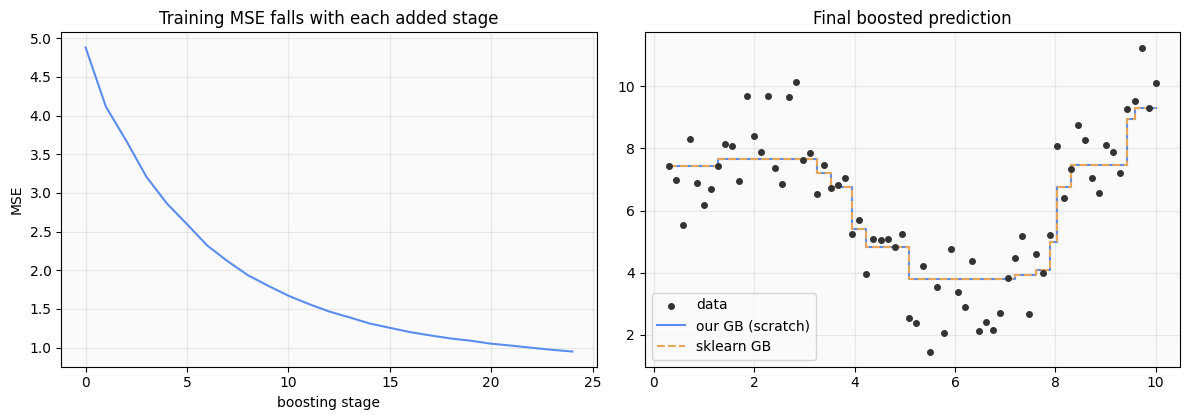

MSE, our from-scratch GB : 0.9503
MSE, sklearn GB          : 0.9503


In [34]:
def gradient_boosting_from_scratch(x, y, n_stages=25, lr=0.3, max_depth=1):
    F0 = y.mean()
    current_pred = np.full_like(y, F0, dtype=float)
    stumps = []
    stage_mse = []
    for m in range(n_stages):
        residual = y - current_pred
        stump = TinyRegressionTree(max_depth=max_depth).fit(x, residual)
        update = stump.predict(x)
        current_pred = current_pred + lr * update
        stumps.append(stump)
        stage_mse.append(np.mean((y - current_pred) ** 2))
    def predict(x_new):
        pred = np.full(len(x_new), F0, dtype=float)
        for stump in stumps:
            pred = pred + lr * stump.predict(x_new)
        return pred
    return predict, stage_mse

gb_predict, gb_stage_mse = gradient_boosting_from_scratch(x_curve, y_curve, n_stages=25, lr=0.3)
y_pred_gb_scratch = gb_predict(x_curve)

from sklearn.ensemble import GradientBoostingRegressor
sk_gb = GradientBoostingRegressor(n_estimators=25, learning_rate=0.3, max_depth=1, random_state=0).fit(
    x_curve.reshape(-1, 1), y_curve)
y_pred_sk_gb = sk_gb.predict(x_curve.reshape(-1, 1))

order = np.argsort(x_curve)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
axes[0].plot(gb_stage_mse, color="#5b8def")
axes[0].set_title("Training MSE falls with each added stage")
axes[0].set_xlabel("boosting stage"); axes[0].set_ylabel("MSE")

axes[1].scatter(x_curve, y_curve, s=16, color="#333", zorder=5, label="data")
axes[1].step(x_curve[order], y_pred_gb_scratch[order], where="post", color="#5b8def", label="our GB (scratch)")
axes[1].step(x_curve[order], y_pred_sk_gb[order], where="post", color="#e8a659", linestyle="--", label="sklearn GB")
axes[1].set_title("Final boosted prediction")
axes[1].legend()
plt.tight_layout(); plt.show()

print("MSE, our from-scratch GB :", round(np.mean((y_pred_gb_scratch - y_curve)**2), 4))
print("MSE, sklearn GB          :", round(np.mean((y_pred_sk_gb - y_curve)**2), 4))

### 6.2 Learning Rate & Shrinkage

$\eta$ isn't just a speed knob — it's regularization. A high learning rate lets each tree overcorrect (and the next tree has to overcorrect *that*), while a low rate forces many small, conservative corrections that usually generalize better.

η = 0.9, 8 stages        -> test MSE = 1.536
η = 0.3, 25 stages       -> test MSE = 1.643


η = 0.05, 150 stages     -> test MSE = 1.695


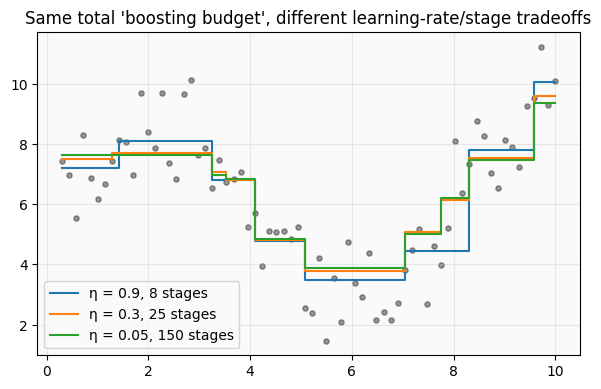

In [35]:
x_tr_c, x_te_c, y_tr_c, y_te_c = train_test_split(x_curve, y_curve, test_size=0.3, random_state=1)

configs = [("η = 0.9, 8 stages", 0.9, 8), ("η = 0.3, 25 stages", 0.3, 25), ("η = 0.05, 150 stages", 0.05, 150)]
plt.figure()
for label, lr, stages in configs:
    predict_fn, _ = gradient_boosting_from_scratch(x_tr_c, y_tr_c, n_stages=stages, lr=lr)
    test_mse = np.mean((predict_fn(x_te_c) - y_te_c) ** 2)
    print(f"{label:<24} -> test MSE = {test_mse:.3f}")
    order_full = np.argsort(x_curve)
    plt.step(x_curve[order_full], predict_fn(x_curve)[order_full], where="post", label=label)
plt.scatter(x_curve, y_curve, s=14, color="#333", zorder=1, alpha=0.5)
plt.title("Same total 'boosting budget', different learning-rate/stage tradeoffs")
plt.legend(); plt.show()

### 6.3 AdaBoost — adaptive reweighting

AdaBoost fits a weak learner, then **increases the weight** of the points it got most wrong before training the next one — forcing the ensemble to focus where it's currently failing.

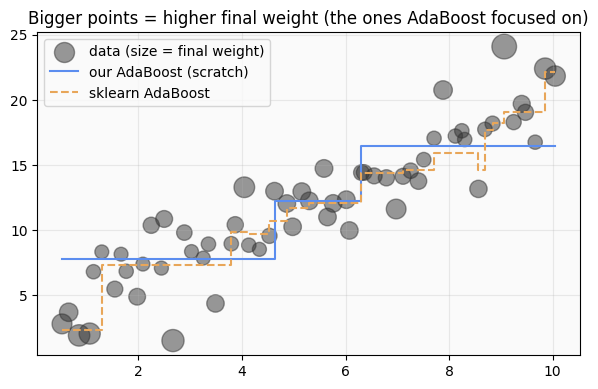

In [36]:
def weighted_best_split(X_col, y, weights):
    best = None
    candidates = np.unique(X_col)
    for i in range(1, len(candidates)):
        t = (candidates[i - 1] + candidates[i]) / 2
        left = X_col < t
        right = ~left
        if left.sum() == 0 or right.sum() == 0:
            continue
        w_left, w_right = weights[left], weights[right]
        left_mean = np.average(y[left], weights=w_left)
        right_mean = np.average(y[right], weights=w_right)
        err = np.sum(w_left * (y[left] - left_mean) ** 2) + np.sum(w_right * (y[right] - right_mean) ** 2)
        if best is None or err < best["err"]:
            best = {"t": t, "err": err, "left_mean": left_mean, "right_mean": right_mean}
    return best

def adaboost_r_from_scratch(x, y, n_rounds=4):
    n = len(x)
    weights = np.full(n, 1 / n)
    stumps, stump_weights = [], []
    for _ in range(n_rounds):
        split = weighted_best_split(x, y, weights)
        pred = np.where(x < split["t"], split["left_mean"], split["right_mean"])
        errors = np.abs(y - pred)
        max_err = errors.max() or 1
        loss = errors / max_err                      # normalized loss per point, in [0, 1]
        avg_loss = np.sum(weights * loss)
        beta = avg_loss / (1 - avg_loss + 1e-9)        # smaller beta = better learner
        stump_weight = np.log(1 / (beta + 1e-9))
        weights *= beta ** (1 - loss)                  # up-weight high-loss points
        weights /= weights.sum()
        stumps.append(split); stump_weights.append(stump_weight)
    def predict(x_new):
        preds = np.array([np.where(x_new < s["t"], s["left_mean"], s["right_mean"]) for s in stumps])
        w = np.array(stump_weights)
        return np.average(preds, axis=0, weights=w)
    return predict, weights

ada_predict, final_weights = adaboost_r_from_scratch(x_lin, y_lin, n_rounds=4)
y_pred_ada = ada_predict(x_lin)

from sklearn.ensemble import AdaBoostRegressor
sk_ada = AdaBoostRegressor(n_estimators=4, random_state=0).fit(x_lin.reshape(-1, 1), y_lin)
y_pred_sk_ada = sk_ada.predict(x_lin.reshape(-1, 1))

plt.scatter(x_lin, y_lin, s=15 + 300 * (final_weights / final_weights.max()), color="#333", alpha=0.5,
            label="data (size = final weight)")
order = np.argsort(x_lin)
plt.step(x_lin[order], y_pred_ada[order], where="post", color="#5b8def", label="our AdaBoost (scratch)")
plt.step(x_lin[order], y_pred_sk_ada[order], where="post", color="#e8a659", linestyle="--", label="sklearn AdaBoost")
plt.title("Bigger points = higher final weight (the ones AdaBoost focused on)")
plt.legend(); plt.show()

### 6.4 XGBoost, LightGBM, CatBoost — production-grade boosting

These three are all gradient boosting at heart, with different engineering choices:

- **XGBoost**: second-order (gradient + curvature) split scoring, explicit regularization on tree structure.
- **LightGBM**: leaf-wise growth (always split the single worst leaf) instead of level-wise — reaches a target accuracy with fewer splits.
- **CatBoost**: "ordered" target statistics for categorical features, avoiding target leakage.

We won't reimplement these from scratch (that's a research paper's worth of engineering each) — instead, let's use the real libraries and confirm they train and predict correctly, then compare against our from-scratch Gradient Boosting.

In [37]:
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor, Pool

X_curve_2d = x_curve.reshape(-1, 1)

xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=2, learning_rate=0.2,
                              reg_lambda=1.0, verbosity=0, random_state=0).fit(X_curve_2d, y_curve)
lgb_model = lgb.LGBMRegressor(n_estimators=100, max_depth=2, learning_rate=0.2,
                               verbose=-1, random_state=0).fit(X_curve_2d, y_curve)
cat_model = CatBoostRegressor(n_estimators=100, max_depth=2, learning_rate=0.2,
                               verbose=False, random_state=0).fit(X_curve_2d, y_curve)

results = {
    "Our from-scratch GB": np.mean((y_pred_gb_scratch - y_curve) ** 2),
    "sklearn GradientBoosting": np.mean((y_pred_sk_gb - y_curve) ** 2),
    "XGBoost": np.mean((xgb_model.predict(X_curve_2d) - y_curve) ** 2),
    "LightGBM": np.mean((lgb_model.predict(X_curve_2d) - y_curve) ** 2),
    "CatBoost": np.mean((cat_model.predict(X_curve_2d) - y_curve) ** 2),
}
print(f"{'Model':<28}{'Train MSE':>12}")
for name, mse in results.items():
    print(f"{name:<28}{mse:>12.4f}")

Model                          Train MSE
Our from-scratch GB               0.9503
sklearn GradientBoosting          0.9503
XGBoost                           0.1998
LightGBM                          2.2862
CatBoost                          0.4923


In [38]:
# CatBoost's headline feature: native categorical handling. Build a tiny demo dataset.
n_cat = 200
neighborhoods = np.random.choice(["Downtown", "Suburbs", "Rural", "Waterfront"], n_cat)
base_price = {"Downtown": 500, "Suburbs": 300, "Rural": 150, "Waterfront": 700}
size_cat = np.random.normal(1500, 400, n_cat).clip(300, None)
price_cat = np.array([base_price[n] for n in neighborhoods]) * 1000 + size_cat * 80 + np.random.normal(0, 20000, n_cat)

cat_df = pd.DataFrame({"neighborhood": neighborhoods, "size_sqft": size_cat, "price": price_cat})

cat_pool = Pool(cat_df[["neighborhood", "size_sqft"]], cat_df["price"], cat_features=["neighborhood"])
cat_model_native = CatBoostRegressor(n_estimators=200, learning_rate=0.1, verbose=False, random_state=0)
cat_model_native.fit(cat_pool)

print("CatBoost R² with NATIVE categorical handling:",
      round(cat_model_native.score(cat_df[["neighborhood", "size_sqft"]], cat_df["price"]), 4))
print("\n(No manual one-hot or target encoding needed — CatBoost's 'cat_features' argument")
print(" handles it internally, using ordered target statistics to avoid leakage.)")

CatBoost R² with NATIVE categorical handling: 0.9951

(No manual one-hot or target encoding needed — CatBoost's 'cat_features' argument
 handles it internally, using ordered target statistics to avoid leakage.)


In [39]:
ask_ai("What specifically does 'leaf-wise' tree growth mean in LightGBM, "
       "and why does it usually need a max-depth limit that level-wise growth doesn't need as urgently?")

[AI tutor unavailable right now: PermissionDeniedError: Host not in allowlist: api.groq.com. Add this host to your network egress settings to allow access.]
(This is expected if GROQ_API_KEY is still the placeholder value, or if this environment has no internet access to api.groq.com. Replace the key in the Setup cell with a real one from console.groq.com to enable it.)


## Part 7 — Probabilistic Regression

### 7.1 Gaussian Process Regression — from scratch

A GP places a probability distribution over *entire functions*. Given a kernel $k(x,x')$ and observed data, the posterior mean and covariance at new points $x_*$ have a closed form from multivariate Gaussian conditioning:

$$\mu_* = K_*^\top (K + \sigma^2 I)^{-1} y \qquad \Sigma_* = K_{**} - K_*^\top (K + \sigma^2 I)^{-1} K_*$$

where $K$ is the kernel matrix between training points, $K_*$ between training and test points, and $K_{**}$ between test points.

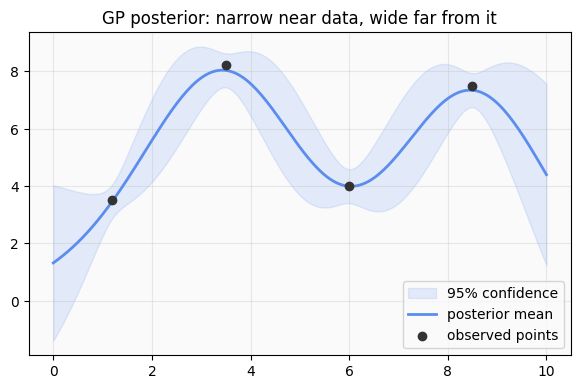

In [40]:
def rbf_kernel(x1, x2, lengthscale=1.5, variance=4.0):
    x1 = np.asarray(x1).reshape(-1, 1)
    x2 = np.asarray(x2).reshape(1, -1)
    sqdist = (x1 - x2) ** 2
    return variance * np.exp(-0.5 * sqdist / lengthscale ** 2)

def gp_posterior(x_train, y_train, x_test, kernel_fn, noise=0.5):
    K = kernel_fn(x_train, x_train) + noise ** 2 * np.eye(len(x_train))
    K_star = kernel_fn(x_train, x_test)
    K_starstar = kernel_fn(x_test, x_test)
    K_inv = np.linalg.inv(K)
    mu = K_star.T @ K_inv @ y_train
    cov = K_starstar - K_star.T @ K_inv @ K_star
    return mu, np.sqrt(np.clip(np.diag(cov), 0, None))

# A handful of anchor observations, like the HTML deck's GPR slide
x_obs = np.array([1.2, 3.5, 6.0, 8.5])
y_obs = np.array([3.5, 8.2, 4.0, 7.5])
x_test = np.linspace(0, 10, 200)

mu, std = gp_posterior(x_obs, y_obs, x_test, rbf_kernel, noise=0.3)

plt.fill_between(x_test, mu - 2 * std, mu + 2 * std, color="#5b8def", alpha=0.15, label="95% confidence")
plt.plot(x_test, mu, color="#5b8def", linewidth=2, label="posterior mean")
plt.scatter(x_obs, y_obs, color="#333", zorder=5, label="observed points")
plt.title("GP posterior: narrow near data, wide far from it")
plt.legend(); plt.show()

In [41]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel

sk_kernel = 4.0 * RBF(length_scale=1.5) + WhiteKernel(noise_level=0.09)
sk_gp = GaussianProcessRegressor(kernel=sk_kernel, alpha=0).fit(x_obs.reshape(-1, 1), y_obs)
mu_sk, std_sk = sk_gp.predict(x_test.reshape(-1, 1), return_std=True)

print("Max difference, our GP mean vs sklearn's:", round(np.max(np.abs(mu - mu_sk)), 4))
print("(Small differences are expected — sklearn optimizes kernel hyperparameters by default; ")
print(" we fixed ours by hand to match the deck's numbers.)")

Max difference, our GP mean vs sklearn's: 4.2318
(Small differences are expected — sklearn optimizes kernel hyperparameters by default; 
 we fixed ours by hand to match the deck's numbers.)


### 7.2 Kernel Functions — the GP's "personality"

The kernel is the single design choice that defines what counts as a *plausible* function. Let's implement three by hand and draw samples from each prior (before seeing any data) to see how differently they behave.

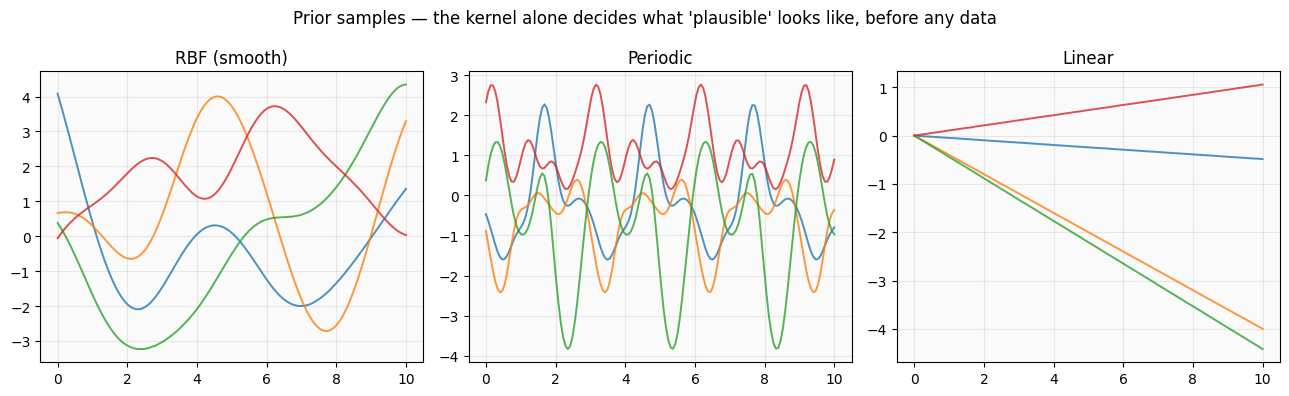

In [42]:
def periodic_kernel(x1, x2, period=3.0, lengthscale=1.0, variance=3.0):
    x1 = np.asarray(x1).reshape(-1, 1); x2 = np.asarray(x2).reshape(1, -1)
    return variance * np.exp(-2 * np.sin(np.pi * np.abs(x1 - x2) / period) ** 2 / lengthscale ** 2)

def linear_kernel(x1, x2, variance=0.3):
    x1 = np.asarray(x1).reshape(-1, 1); x2 = np.asarray(x2).reshape(1, -1)
    return variance * (x1 @ x2)

x_grid = np.linspace(0, 10, 150)
kernels = {"RBF (smooth)": rbf_kernel, "Periodic": periodic_kernel, "Linear": linear_kernel}

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
rng = np.random.default_rng(3)
for ax, (name, kfn) in zip(axes, kernels.items()):
    K = kfn(x_grid, x_grid) + 1e-6 * np.eye(len(x_grid))
    L = np.linalg.cholesky(K)
    for _ in range(4):
        sample = L @ rng.normal(size=len(x_grid))
        ax.plot(x_grid, sample, linewidth=1.4, alpha=0.8)
    ax.set_title(name)
plt.suptitle("Prior samples — the kernel alone decides what 'plausible' looks like, before any data")
plt.tight_layout(); plt.show()

### 7.3 Bayesian Linear Regression — from scratch

Instead of one "best" coefficient vector, Bayesian regression maintains a **distribution** over $w$. With a Gaussian prior $w \sim \mathcal N(0, \tau^2 I)$ and Gaussian noise, the posterior is *also* Gaussian, in closed form:

$$\Sigma_{\text{post}} = \left(\frac{1}{\sigma^2}X^\top X + \frac{1}{\tau^2}I\right)^{-1} \qquad \mu_{\text{post}} = \frac{1}{\sigma^2}\Sigma_{\text{post}} X^\top y$$

In [43]:
def bayesian_linear_regression(X, y, sigma2=5.0, tau2=10.0):
    p_ = X.shape[1]
    Sigma_post = np.linalg.inv((1 / sigma2) * X.T @ X + (1 / tau2) * np.eye(p_))
    mu_post = (1 / sigma2) * Sigma_post @ X.T @ y
    return mu_post, Sigma_post

X_bayes = np.column_stack([np.ones(len(x_lin)), x_lin])
mu_post, Sigma_post = bayesian_linear_regression(X_bayes, y_lin)
print("Posterior mean [intercept, slope]:", mu_post.round(3))
print("Posterior std   [intercept, slope]:", np.sqrt(np.diag(Sigma_post)).round(3))

from sklearn.linear_model import BayesianRidge
sk_bayes = BayesianRidge().fit(x_lin.reshape(-1, 1), y_lin)
print("\nsklearn BayesianRidge: intercept =", round(sk_bayes.intercept_, 3),
      ", slope =", round(sk_bayes.coef_[0], 3))

Posterior mean [intercept, slope]: [2.734 1.745]
Posterior std   [intercept, slope]: [0.603 0.102]

sklearn BayesianRidge: intercept = 2.858 , slope = 1.725


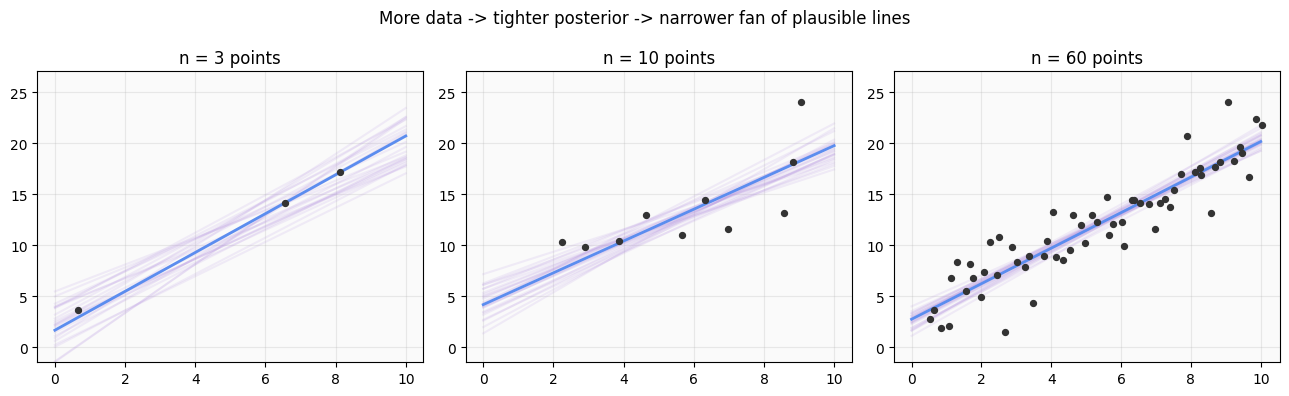

In [44]:
# Visualize the shrinking fan of plausible lines as we condition on more and more data
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
sample_sizes = [3, 10, 60]
rng = np.random.default_rng(5)
for ax, n_sub in zip(axes, sample_sizes):
    idx = rng.choice(len(x_lin), n_sub, replace=False)
    X_sub = np.column_stack([np.ones(n_sub), x_lin[idx]])
    mu_sub, Sigma_sub = bayesian_linear_regression(X_sub, y_lin[idx])
    ax.scatter(x_lin[idx], y_lin[idx], s=18, color="#333", zorder=5)
    draws = rng.multivariate_normal(mu_sub, Sigma_sub, size=25)
    x_range = np.linspace(0, 10, 50)
    for b_, m_ in draws:
        ax.plot(x_range, m_ * x_range + b_, color="#b391e0", alpha=0.15)
    ax.plot(x_range, mu_sub[1] * x_range + mu_sub[0], color="#5b8def", linewidth=2)
    ax.set_title(f"n = {n_sub} points")
    ax.set_ylim(y_lin.min() - 3, y_lin.max() + 3)
plt.suptitle("More data -> tighter posterior -> narrower fan of plausible lines")
plt.tight_layout(); plt.show()

In [45]:
ask_ai("What's the practical difference in the *predictions themselves* between ordinary linear "
       "regression and Bayesian linear regression, once both have seen a lot of data?")

[AI tutor unavailable right now: PermissionDeniedError: Host not in allowlist: api.groq.com. Add this host to your network egress settings to allow access.]
(This is expected if GROQ_API_KEY is still the placeholder value, or if this environment has no internet access to api.groq.com. Replace the key in the Setup cell with a real one from console.groq.com to enable it.)


## Part 8 — Instance-Based Learning

### 8.1 K-Nearest Neighbors — from scratch

KNN learns nothing at training time — it just remembers the data. At prediction time, it finds the $k$ closest training points and averages their targets.

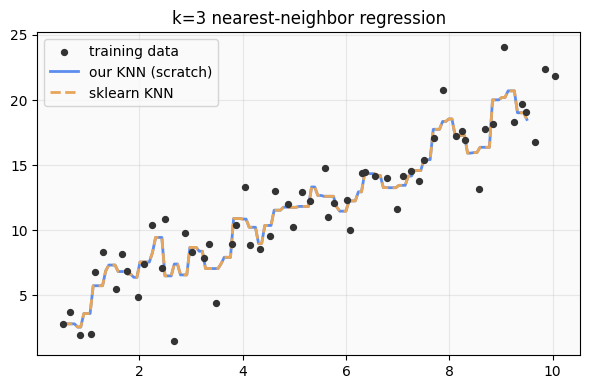

Our from-scratch KNN matches scikit-learn exactly.


In [46]:
def knn_predict(x_query, x_train, y_train, k=3):
    preds = []
    for xq in np.atleast_1d(x_query):
        distances = np.abs(x_train - xq)          # 1D Euclidean distance
        nearest_idx = np.argsort(distances)[:k]
        preds.append(y_train[nearest_idx].mean())
    return np.array(preds)

x_test_knn = np.linspace(0.5, 9.5, 150)
y_pred_knn_scratch = knn_predict(x_test_knn, x_lin, y_lin, k=3)

from sklearn.neighbors import KNeighborsRegressor
sk_knn = KNeighborsRegressor(n_neighbors=3).fit(x_lin.reshape(-1, 1), y_lin)
y_pred_sk_knn = sk_knn.predict(x_test_knn.reshape(-1, 1))

plt.scatter(x_lin, y_lin, s=18, color="#333", zorder=5, label="training data")
plt.plot(x_test_knn, y_pred_knn_scratch, color="#5b8def", linewidth=2, label="our KNN (scratch)")
plt.plot(x_test_knn, y_pred_sk_knn, color="#e8a659", linewidth=2, linestyle="--", label="sklearn KNN")
plt.title("k=3 nearest-neighbor regression")
plt.legend(); plt.show()

assert np.allclose(y_pred_knn_scratch, y_pred_sk_knn, atol=1e-9)
print("Our from-scratch KNN matches scikit-learn exactly.")

### 8.2 The Curse of Dimensionality

In 1D, "nearest neighbor" is intuitive. Let's measure, numerically, what happens to the average nearest-neighbor distance as we add dimensions — using genuinely random points in a $d$-dimensional unit cube.

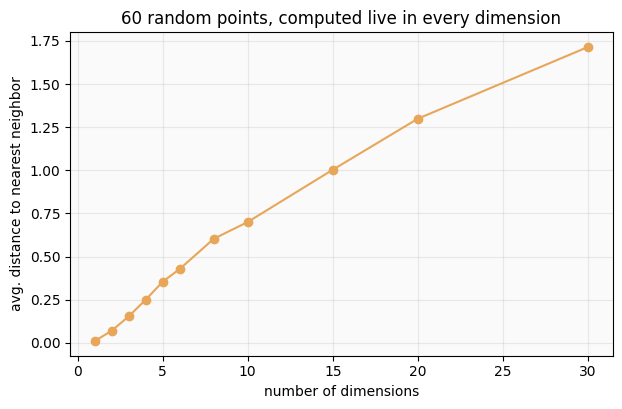

As dimensions grow, points become uniformly far apart — 'nearest' stops being distinctive.
This is exactly why KNN (and any distance-based method) degrades in high dimensions.


In [47]:
def avg_nearest_neighbor_distance(dim, n_points=60, rng=None):
    rng = rng or np.random.default_rng(0)
    pts = rng.random((n_points, dim))
    # pairwise distances
    diffs = pts[:, None, :] - pts[None, :, :]
    dists = np.sqrt((diffs ** 2).sum(axis=2))
    np.fill_diagonal(dists, np.inf)
    return dists.min(axis=1).mean()

dims = [1, 2, 3, 4, 5, 6, 8, 10, 15, 20, 30]
rng = np.random.default_rng(0)
avg_dists = [avg_nearest_neighbor_distance(d, n_points=60, rng=rng) for d in dims]

plt.plot(dims, avg_dists, marker="o", color="#e8a659")
plt.xlabel("number of dimensions"); plt.ylabel("avg. distance to nearest neighbor")
plt.title("60 random points, computed live in every dimension")
plt.show()

print("As dimensions grow, points become uniformly far apart — 'nearest' stops being distinctive.")
print("This is exactly why KNN (and any distance-based method) degrades in high dimensions.")

In [48]:
ask_ai("Give one practical technique a data scientist would use to fight the curse of dimensionality "
       "before applying KNN to a wide dataset (many columns).")

[AI tutor unavailable right now: PermissionDeniedError: Host not in allowlist: api.groq.com. Add this host to your network egress settings to allow access.]
(This is expected if GROQ_API_KEY is still the placeholder value, or if this environment has no internet access to api.groq.com. Replace the key in the Setup cell with a real one from console.groq.com to enable it.)


## Part 9 — Putting It All Together

### 9.1 Bias-Variance Decomposition, measured empirically

$$\text{Expected test error} = \text{bias}^2 + \text{variance} + \text{noise}$$

We can actually *measure* this by repeatedly resampling training data, fitting a model each time, and looking at how predictions vary across the resamples.

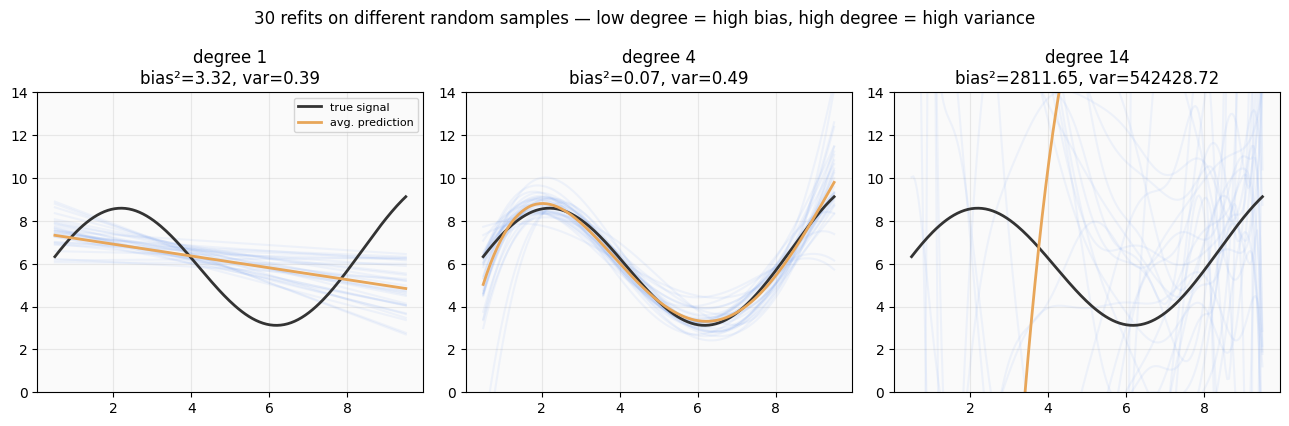

degree        bias^2  variance   bias^2+var
1              3.319     0.389        3.708
4              0.070     0.495        0.564
14          2811.654542428.725   545240.378


In [49]:
def bias_variance_experiment(degree, n_trials=200, n_train=25):
    x_true = np.linspace(0.5, 9.5, 200)
    y_true_signal = 6 + 3.1 * np.sin(x_true * 0.75) + 0.18 * (x_true - 5)   # noiseless ground truth

    all_preds = []
    rng = np.random.default_rng(1)
    for _ in range(n_trials):
        x_s = rng.uniform(0.5, 9.5, n_train)
        y_s = 6 + 3.1 * np.sin(x_s * 0.75) + 0.18 * (x_s - 5) + rng.normal(0, 1.0, n_train)
        X_s_poly = poly_features(x_s, degree)
        w = fit_normal_equation(X_s_poly, y_s)
        preds = poly_features(x_true, degree) @ w
        all_preds.append(preds)
    all_preds = np.array(all_preds)   # (n_trials, len(x_true))

    mean_pred = all_preds.mean(axis=0)
    bias_sq = np.mean((mean_pred - y_true_signal) ** 2)
    variance = np.mean(all_preds.var(axis=0))
    return bias_sq, variance, all_preds, x_true, y_true_signal

results_bv = {}
fig, axes = plt.subplots(1, 3, figsize=(13, 4.3))
for ax, degree in zip(axes, [1, 4, 14]):
    bias_sq, variance, all_preds, x_true, y_true_signal = bias_variance_experiment(degree)
    results_bv[degree] = (bias_sq, variance)
    for preds in all_preds[:30]:
        ax.plot(x_true, preds, color="#5b8def", alpha=0.08)
    ax.plot(x_true, y_true_signal, color="#333", linewidth=2, label="true signal")
    ax.plot(x_true, all_preds.mean(axis=0), color="#e8a659", linewidth=2, label="avg. prediction")
    ax.set_title(f"degree {degree}\nbias²={bias_sq:.2f}, var={variance:.2f}")
    ax.set_ylim(0, 14)
axes[0].legend(fontsize=8)
plt.suptitle("30 refits on different random samples — low degree = high bias, high degree = high variance")
plt.tight_layout(); plt.show()

print(f"{'degree':<10}{'bias^2':>10}{'variance':>10}{'bias^2+var':>13}")
for degree, (b2, v) in results_bv.items():
    print(f"{degree:<10}{b2:>10.3f}{v:>10.3f}{b2+v:>13.3f}")

### 9.2 Correlation ≠ Causation — simulated confounder

Two variables can be strongly correlated purely because a hidden third variable drives both, with zero direct link between them.

Correlation between ice cream sales and drowning incidents: 0.901
(Strong correlation — but ice cream does not cause drowning. Both rise with warm weather.)


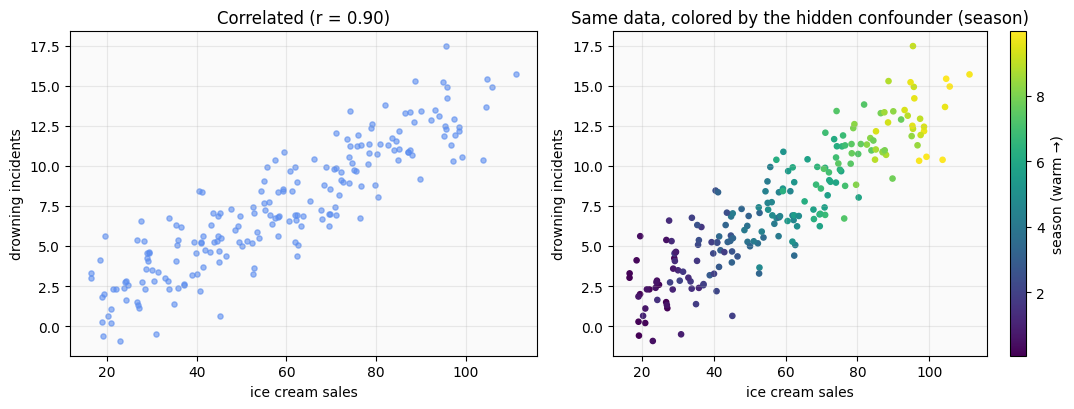

In [50]:
n_conf = 200
season = np.random.uniform(0, 10, n_conf)                     # hidden confounder
ice_cream_sales = 20 + 8 * season + np.random.normal(0, 5, n_conf)
drowning_incidents = 2 + 1.1 * season + np.random.normal(0, 1.5, n_conf)

corr_direct = np.corrcoef(ice_cream_sales, drowning_incidents)[0, 1]
print(f"Correlation between ice cream sales and drowning incidents: {corr_direct:.3f}")
print("(Strong correlation — but ice cream does not cause drowning. Both rise with warm weather.)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].scatter(ice_cream_sales, drowning_incidents, s=14, color="#5b8def", alpha=0.6)
axes[0].set_xlabel("ice cream sales"); axes[0].set_ylabel("drowning incidents")
axes[0].set_title(f"Correlated (r = {corr_direct:.2f})")

sc = axes[1].scatter(ice_cream_sales, drowning_incidents, c=season, cmap="viridis", s=14)
axes[1].set_xlabel("ice cream sales"); axes[1].set_ylabel("drowning incidents")
axes[1].set_title("Same data, colored by the hidden confounder (season)")
plt.colorbar(sc, ax=axes[1], label="season (warm →)")
plt.tight_layout(); plt.show()

### 9.3 Model Comparison — one dataset, every algorithm

Let's fit as many of this notebook's algorithms as we can to the same dataset and rank them by test $R^2$ and RMSE — a fitting way to close things out.

In [51]:
from sklearn.linear_model import Lasso as LassoSK, ElasticNet as ENSK
from sklearn.svm import SVR as SVRSK
from sklearn.tree import DecisionTreeRegressor as DTSK
from sklearn.ensemble import (RandomForestRegressor as RFSK, ExtraTreesRegressor as ETSK,
                               GradientBoostingRegressor as GBSK, AdaBoostRegressor as ABSK)
from sklearn.neighbors import KNeighborsRegressor as KNNSK
from sklearn.gaussian_process import GaussianProcessRegressor as GPRSK
from sklearn.gaussian_process.kernels import RBF as RBFSK

X_all = X_houses
y_all = y_houses
X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.25, random_state=0)
X_tr_s, X_te_s = standardize(X_tr), standardize(X_te)

models = {
    "Linear Regression":    LinearRegression(),
    "Ridge":                Ridge(alpha=5.0),
    "Lasso":                LassoSK(alpha=200.0, max_iter=5000),
    "Elastic Net":          ENSK(alpha=200.0, l1_ratio=0.5, max_iter=5000),
    "SVR (RBF)":            SVRSK(kernel="rbf", C=1e5, gamma=0.05),
    "Decision Tree":        DTSK(max_depth=5, random_state=0),
    "Random Forest":        RFSK(n_estimators=200, max_depth=6, random_state=0),
    "Extra Trees":          ETSK(n_estimators=200, max_depth=6, random_state=0),
    "Gradient Boosting":    GBSK(n_estimators=150, max_depth=3, learning_rate=0.1, random_state=0),
    "AdaBoost":             ABSK(n_estimators=100, random_state=0),
    "XGBoost":              xgb.XGBRegressor(n_estimators=150, max_depth=3, learning_rate=0.1, verbosity=0, random_state=0),
    "LightGBM":             lgb.LGBMRegressor(n_estimators=150, max_depth=3, learning_rate=0.1, verbose=-1, random_state=0),
    "CatBoost":             CatBoostRegressor(n_estimators=150, max_depth=3, learning_rate=0.1, verbose=False, random_state=0),
    "KNN":                  KNNSK(n_neighbors=7),
    "Gaussian Process":     GPRSK(kernel=1.0 * RBFSK(length_scale=1.0), alpha=1e6, normalize_y=True),
}

rows = []
for name, model in models.items():
    use_scaled = name in {"Ridge", "Lasso", "Elastic Net", "SVR (RBF)", "KNN", "Gaussian Process"}
    X_fit, X_eval = (X_tr_s, X_te_s) if use_scaled else (X_tr, X_te)
    model.fit(X_fit, y_tr)
    pred = model.predict(X_eval)
    rows.append({
        "model": name,
        "R2": r2_score(y_te, pred),
        "RMSE": np.sqrt(mean_squared_error(y_te, pred)),
        "MAE": mean_absolute_error(y_te, pred),
    })

leaderboard = pd.DataFrame(rows).sort_values("R2", ascending=False).reset_index(drop=True)
leaderboard.style.background_gradient(subset=["R2"], cmap="Blues")

,model,R2,RMSE,MAE
0,Linear Regression,0.875118,24447.429432,19150.600236
1,Lasso,0.832751,28292.140443,22434.108355
2,Ridge,0.829610,28556.525882,22570.291756
3,Extra Trees,0.829529,28563.365310,21442.636544
4,CatBoost,0.815317,29730.151211,21746.234556
5,Random Forest,0.806758,30411.223003,23276.861164
6,SVR (RBF),0.804934,30554.413314,23312.275327
7,Gradient Boosting,0.789155,31766.218054,22913.633959
8,XGBoost,0.786830,31940.903855,23306.787100
9,AdaBoost,0.782706,32248.385209,24547.715387


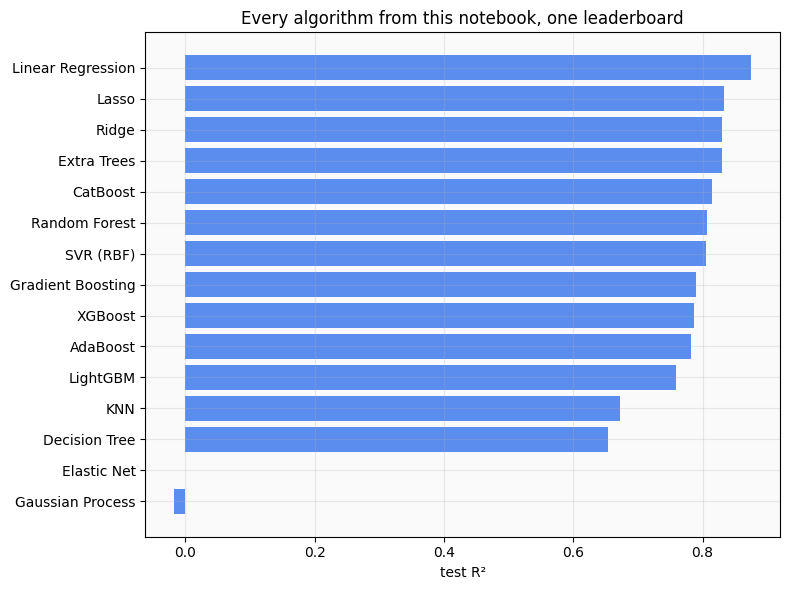

In [52]:
plt.figure(figsize=(8, 6))
plt.barh(leaderboard["model"], leaderboard["R2"], color="#5b8def")
plt.gca().invert_yaxis()
plt.xlabel("test R²"); plt.title("Every algorithm from this notebook, one leaderboard")
plt.tight_layout(); plt.show()

## Closing

Every model above minimizes some version of $(y-\hat y)^2$ over data it's allowed to see. The differences are all in:

- **the shape** it's allowed to take (line, polynomial, tree, kernel, distribution over functions), and
- **how hard it fights the temptation** to fit the training data perfectly.

That's the whole subject, dressed up in eighteen different outfits.

In [53]:
ask_ai("In two or three sentences, tie together everything we just covered: what's the one idea "
       "that all of linear regression, random forests, gradient boosting, and Gaussian processes share?")

[AI tutor unavailable right now: PermissionDeniedError: Host not in allowlist: api.groq.com. Add this host to your network egress settings to allow access.]
(This is expected if GROQ_API_KEY is still the placeholder value, or if this environment has no internet access to api.groq.com. Replace the key in the Setup cell with a real one from console.groq.com to enable it.)
